# Taller Deep Learning

## 0. Librerías

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf

from sklearn.preprocessing import StandardScaler#, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error

warnings.simplefilter(action="ignore", category=FutureWarning)

np.random.seed(42)

## 1. Lectura y preprocesado de datos

Leemos los datos de los precios de cierre de las 23 acciones desde 1945. Vemos que solo hay datos desde 1962, así que tendremos datos desde ese mismo año.

In [ ]:
# Leemos los datos de los precios de cierre de las acciones desde 1945 hasta la fecha actual
#start_date = '1945-01-01'
#tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']
#precios_close = yf.download(tickers_validos, start=start_date, auto_adjust=True, progress=True)['Close']
#precios_close.head()

[*********************100%***********************]  23 of 23 completed


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462332,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617245,...,0.830128,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892468,0.194749,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611052,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606347,0.237781,0.090291
1962-01-05,0.859896,0.189022,0.483348,0.274553,0.296847,0.058012,0.372256,0.234863,0.175207,0.588343,...,0.824461,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602781,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295456,0.057821,0.373051,0.235978,0.178021,0.587311,...,0.807461,0.056902,0.042640,0.031457,0.541381,0.002368,0.058579,0.592079,0.229766,0.088095


In [2]:
precios_close = pd.read_csv('precios_activos.csv', header=0, index_col=0)
precios_close.index = pd.to_datetime(precios_close.index, errors='coerce')
precios_close.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,0.894096,0.190931,0.462333,0.284116,0.307970,0.057055,0.386574,0.240809,0.168170,0.617244,...,0.830127,0.060341,0.044744,0.031859,0.554942,0.002384,0.063742,0.613480,0.244460,0.088754
1962-01-03,0.892467,0.194750,0.466836,0.281340,0.307275,0.057821,0.383392,0.240809,0.173799,0.611051,...,0.818794,0.059403,0.043747,0.032528,0.559115,0.002341,0.061072,0.611697,0.241788,0.090072
1962-01-04,0.879439,0.192840,0.478844,0.281340,0.304494,0.057821,0.380211,0.240066,0.174503,0.603827,...,0.815961,0.058778,0.044080,0.032394,0.559115,0.002357,0.060449,0.606346,0.237781,0.090291
1962-01-05,0.859895,0.189022,0.483347,0.274553,0.296847,0.058012,0.372257,0.234863,0.175207,0.588344,...,0.824460,0.057840,0.043083,0.031591,0.544511,0.002384,0.058401,0.602780,0.236111,0.088314
1962-01-08,0.853381,0.189499,0.486350,0.271468,0.295457,0.057821,0.373052,0.235978,0.178021,0.587312,...,0.807462,0.056902,0.042640,0.031457,0.541382,0.002368,0.058579,0.592080,0.229766,0.088095


Observamos que no hay problemas de valores nulos

In [3]:
precios_close.isna().sum()

AEP    0
BA     0
CAT    0
CNP    0
CVX    0
DIS    0
DTE    0
ED     0
GD     0
GE     0
HON    0
HPQ    0
IBM    0
IP     0
JNJ    0
KO     0
KR     0
MMM    0
MO     0
MRK    0
MSI    0
PG     0
XOM    0
dtype: int64

Finalmente calculamos los retornos de las acciones durante todo el periodo.

In [3]:
# Calculamos los retornos logarítmicos de los precios de cierre
returns = np.log(precios_close).diff().dropna()
returns.head()

,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009819,-0.002260,0.013333,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015671,-0.022531,0.020790,0.007491,-0.018518,-0.042803,-0.002911,-0.010989,0.014742
1962-01-04,-0.014705,-0.009852,0.025398,0.000000,-0.009090,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003466,-0.010578,0.007569,-0.004123,0.000000,0.006985,-0.010256,-0.008785,-0.016714,0.002436
1962-01-05,-0.022473,-0.020001,0.009360,-0.024419,-0.025436,0.003308,-0.021142,-0.021910,0.004025,-0.025975,...,0.010362,-0.016090,-0.022875,-0.025107,-0.026467,0.011534,-0.034462,-0.005899,-0.007047,-0.022141
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002134,0.004736,0.015936,-0.001756,...,-0.020833,-0.016348,-0.010335,-0.004245,-0.005763,-0.006905,0.003043,-0.017911,-0.027242,-0.002491
1962-01-09,-0.007663,0.002516,0.009217,0.000000,0.014019,0.019676,0.002131,-0.001577,0.003945,0.005258,...,-0.014135,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004550,-0.024391,-0.001453,-0.002497


La función `create_time_series_data` divide los datos en ventanas de entrada y salida. 

- Las dimensiones de los datos predictores es $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $retornos$ $(ventana$ $de$ $entrada),$ $número$ $de$ $activos)$. Es decir, tenemos tantas particiones como $número$ $de$ $datos$ - $ventana$ $de$ $entrada$ - $ventana$ $de$ $salida + 1$. Cada partición tiene los $ventana$ $de$ $entrada$ retornos. En la primera partición, el primer retorno es el primer retorno de la serie, en la segunda es el segundo retorno y así se van corriendo los retornos sucesivamente. Por último, se aplica todo esto para cada uno de los 23 activos.

- Las dimensiones de los datos a predecir son $(Número$ $de$ $observaciones,$ $Número$ $de$ $activos)$. Tenemos tantos valores a predecir como $(Número$ $de$ $series$ $temporales,$ $número$ $de$ $activos)$. Se consigue reducir la dimensión $Número$ $de$ $retornos$ $(ventana$ $de$ $salida)$ porque sobre esos retornos se calcula la media. Es decir, los valores a predecir son realmente la media de los retornos de la ventana de salida. La ventana de salida está compuesta por los N siguientes retornos que siguen a los retornos que se encuentran en la ventana de entrada. 

Por lo tanto, no hay saltos entre los datos de entrada y salida de los modelos. Lopez de Prado lo recomienda pero en este caso no se utlizará.

In [4]:
def create_time_series_data(data, input_window_size, output_window_size):
    """
    Genera secuencias de entrada y promedios de salida para datos de series temporales.

    Args:
        data (pd.DataFrame o np.array): Los datos de la serie temporal.
        input_window_size (int): El número de pasos de tiempo para la secuencia de entrada (X).
        output_window_size (int): El número de pasos de tiempo para calcular el promedio de la salida (y).

    Returns:
        tuple: (X, y) donde X son las secuencias de entrada y y son los promedios de salida.
               X tendrá la forma (num_samples, input_window_size, num_features).
               y tendrá la forma (num_samples, num_features) si output_window_size > 0.
               Si output_window_size == 0, y contendrá el último valor de la ventana de entrada.
    """
    X, y = [], []
    # Asegúrate de que los datos sean un array numpy para un manejo consistente
    data_array = data.values if isinstance(data, pd.DataFrame) else data

    num_features = data_array.shape[1] # Obtiene el número de características

    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        # Secuencia de entrada
        input_sequence = data_array[i : i + input_window_size]
        X.append(input_sequence)

        # Salida: promedio de los siguientes 'output_window_size' pasos
        # O si output_window_size es 0, toma el último valor de la ventana de entrada como 'y'
        if output_window_size > 0:
            output_sequence = data_array[i + input_window_size : i + input_window_size + output_window_size]
            average_output = np.mean(output_sequence, axis=0) # Promedio a lo largo de la ventana para cada característica
            y.append(average_output)
        else: # Si output_window_size es 0, la 'salida' es simplemente el último punto de la ventana de entrada
            y.append(data_array[i + input_window_size - 1])

    return np.array(X), np.array(y)

Generamos dos diccionarios que almacenarán para cada combinación de datos de entrada y salida. 

- `dicc_data`: Almacena los datos X.
- `dicc_target`: Almacena la variable a predecir y.

In [5]:
# Definimos en dos listas los parámetros de las ventanas de entrada y salida. Definimos el diccionario que almacenará los datos
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida = [1, 5, 30, 90]
dicc_data = {}
dicc_target = {}

for entrada in ventanas_entrada:
    for salida in ventanas_salida:
        dicc_data[(entrada, salida)], dicc_target[(entrada, salida)] = create_time_series_data(returns, entrada, salida)

In [6]:
# Comprobamos que las particiones son adecuadas.
for key in dicc_data.keys():
    print(f"Combinación de parámetros de entrada y salida: {key}")
    print(dicc_data[key].shape)
    print(dicc_target[key].shape)
    print()

Combinación de parámetros de entrada y salida: (5, 1)
(16185, 5, 23)
(16185, 23)

Combinación de parámetros de entrada y salida: (5, 5)
(16181, 5, 23)
(16181, 23)

Combinación de parámetros de entrada y salida: (5, 30)
(16156, 5, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (5, 90)
(16096, 5, 23)
(16096, 23)

Combinación de parámetros de entrada y salida: (10, 1)
(16180, 10, 23)
(16180, 23)

Combinación de parámetros de entrada y salida: (10, 5)
(16176, 10, 23)
(16176, 23)

Combinación de parámetros de entrada y salida: (10, 30)
(16151, 10, 23)
(16151, 23)

Combinación de parámetros de entrada y salida: (10, 90)
(16091, 10, 23)
(16091, 23)

Combinación de parámetros de entrada y salida: (30, 1)
(16160, 30, 23)
(16160, 23)

Combinación de parámetros de entrada y salida: (30, 5)
(16156, 30, 23)
(16156, 23)

Combinación de parámetros de entrada y salida: (30, 30)
(16131, 30, 23)
(16131, 23)

Combinación de parámetros de entrada y salida: (30, 90)
(16071, 30, 23)
(16071,

Dividimos los datos en train (90%) y test (10%). Posteriormente, cuando se entrenen modelos de Deep Learning habrá que volver a dividir los datos train en validación. Incluimos la semilla 42 y el parámetro suffle que nos asegurá que los datos train siempre son anteriores a los test. De otro modo, veríamos el futuro y el modelo no tendría sentido.

In [7]:
# Debemos separar los datos de cada una de las combinaciones en train y test -> (90-10)
from sklearn.model_selection import train_test_split
RANDOM_SEED = 42
dicc_data_train = {}
dicc_data_train_reg = {}
dicc_data_val = {}
dicc_data_test = {}
dicc_target_train = {}
dicc_target_train_reg = {}
dicc_target_val = {}
dicc_target_test = {}

# Obtenemos la partición train - test
for key in dicc_data.keys():
    dicc_data_train[key], dicc_data_test[key], dicc_target_train[key], dicc_target_test[key] = train_test_split(dicc_data[key], dicc_target[key], test_size=0.1, shuffle=False, random_state=RANDOM_SEED)

# Obtenemos la partición train - val
for key in dicc_data.keys():
    dicc_data_train_reg[key], dicc_data_val[key], dicc_target_train_reg[key], dicc_target_val[key] = train_test_split(dicc_data_train[key], dicc_target_train[key], test_size=0.25, shuffle=False, random_state=RANDOM_SEED)

In [29]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_reg[key].shape)
    print(dicc_data_val[key].shape)
    print(dicc_data_test[key].shape)
    print(dicc_target_train_reg[key].shape)
    print(dicc_target_val[key].shape)
    print(dicc_target_test[key].shape)
    print()

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)
(10924, 23)
(3642, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)
(10921, 23)
(3641, 23)
(1619, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)
(10905, 23)
(3635, 23)
(1616, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)
(10864, 23)
(3622, 23)
(1610, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)
(10921, 23)
(3641, 23)
(1618, 23)

Dimensiones de los datos particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 

Estandarizamos los datos con `Standard Scaler`. Normalizamos los datos train y transformamos los test en base al modelo que hemos entrenado con train.

In [23]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_data_train_norm = {}
dicc_data_val_norm = {}
dicc_data_test_norm = {}

for key in dicc_data_train.keys():
    X_train_reshaped = dicc_data_train_reg[key].reshape(-1, 23)
    X_val_reshaped = dicc_data_val[key].reshape(-1, 23)
    X_test_reshaped = dicc_data_test[key].reshape(-1, 23)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_val_scaled = scaler.transform(X_val_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    dicc_data_train_norm[key] = X_train_scaled.reshape(dicc_data_train_reg[key].shape[0], dicc_data_train_reg[key].shape[1], dicc_data_train_reg[key].shape[2])
    dicc_data_val_norm[key] = X_val_scaled.reshape(dicc_data_val[key].shape[0], dicc_data_val[key].shape[1], dicc_data_val[key].shape[2])
    dicc_data_test_norm[key] = X_test_scaled.reshape(dicc_data_test[key].shape[0], dicc_data_test[key].shape[1], dicc_data_test[key].shape[2])

In [24]:
# Normalizamos los datos train y transformamos los test para cada una de las combinaciones
dicc_target_train_norm = {}
dicc_target_val_norm = {}
dicc_target_test_norm = {}
dicc_scaler = {}

for key in dicc_data_train.keys():
    y_train = dicc_target_train_reg[key]
    y_val = dicc_target_val[key]
    y_test = dicc_target_test[key]

    scaler = StandardScaler()
    dicc_target_train_norm[key] = scaler.fit_transform(y_train)
    dicc_target_val_norm[key] = scaler.transform(y_val)
    dicc_target_test_norm[key] = scaler.transform(y_test)

    dicc_scaler[key] = scaler

In [19]:
# Comprobación de que las particiones train-test se han realizado correctamente
for key in dicc_data.keys():
    print(f'Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: {key}')
    print(dicc_data_train_norm[key].shape)
    print(dicc_data_val_norm[key].shape)
    print(dicc_data_test_norm[key].shape)
    print()

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 1)
(10924, 5, 23)
(3642, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 5)
(10921, 5, 23)
(3641, 5, 23)
(1619, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 30)
(10905, 5, 23)
(3635, 5, 23)
(1616, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (5, 90)
(10864, 5, 23)
(3622, 5, 23)
(1610, 5, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 1)
(10921, 10, 23)
(3641, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación de datos de entrada y salida: (10, 5)
(10918, 10, 23)
(3640, 10, 23)
(1618, 10, 23)

Dimensiones de los datos normalizados particionados para la combinación 

## 2. Establecimiento de los modelos baselines

Los baselines son modelos simples que usan modelos como la regresión lineal y que sirven para valorar la calidad de los modelos de Deep Learning que diseñemos.

En este caso usaremos la estrategia Buy & Hold y la regresión lineal.

In [25]:
dicc_train_flat = {}
dicc_val_flat = {}
dicc_test_flat = {}

for key in dicc_data.keys():
    num_samples_train = dicc_data_train_norm[key].shape[0]
    num_samples_val = dicc_data_val_norm[key].shape[0]
    num_samples_test = dicc_data_test_norm[key].shape[0]

    # Flatten X_train_seq to (num_samples, input_window_size * num_features)
    dicc_train_flat[key] = dicc_data_train_norm[key].reshape(num_samples_train, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_val_flat[key] = dicc_data_val_norm[key].reshape(num_samples_val, -1)

    # Flatten X_test_seq to (num_samples, input_window_size * num_features)
    dicc_test_flat[key] = dicc_data_test_norm[key].reshape(num_samples_test, -1)

Entrenamos un modelo de regresión lineal con los datos que disponemos en las tres particiones. Este modelo será el que usaremos como baseline.

Se entrena un modelo para cada par de datos de entrada y salida.

In [ ]:
from sklearn.linear_model import LinearRegression

mae_reg_train = {}
mae_reg_val = {}
mae_reg_test = {}

for key in dicc_data.keys():
    # Inicializar el modelo de regresión lineal
    linear_model = LinearRegression()

    # Entrenar el modelo con los datos aplanados
    linear_model.fit(dicc_train_flat[key], dicc_target_train_norm[key])

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_train = linear_model.predict(dicc_train_flat[key])
    y_pred_linear_train = dicc_scaler[key].inverse_transform(y_pred_linear_train)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_val = linear_model.predict(dicc_val_flat[key])
    y_pred_linear_val = dicc_scaler[key].inverse_transform(y_pred_linear_val)

    # Realizar predicciones en el conjunto de prueba aplanado
    y_pred_linear_test = linear_model.predict(dicc_test_flat[key])
    y_pred_linear_test = dicc_scaler[key].inverse_transform(y_pred_linear_test)

    mae_train = mean_absolute_error(y_pred_linear_train, dicc_target_train_reg[key])
    mae_val = mean_absolute_error(y_pred_linear_val,dicc_target_val[key])
    mae_test = mean_absolute_error(y_pred_linear_test,dicc_target_test[key])

    mae_reg_train[key], mae_reg_val[key], mae_reg_test[key] = mae_train, mae_val, mae_test

In [36]:
# Initialize matrices to store MAE results
mae_train_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_val_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))
mae_test_matrix = np.zeros((len(ventanas_entrada), len(ventanas_salida)))

# Loop through all combinations of window sizes
for i, entrada in enumerate(ventanas_entrada):
    for j, salida in enumerate(ventanas_salida):
        # Store MAE in matrices
        mae_train_matrix[i][j] = mae_reg_train[(entrada, salida)]
        mae_val_matrix[i][j] = mae_reg_val[(entrada, salida)]
        mae_test_matrix[i][j] = mae_reg_test[(entrada, salida)]

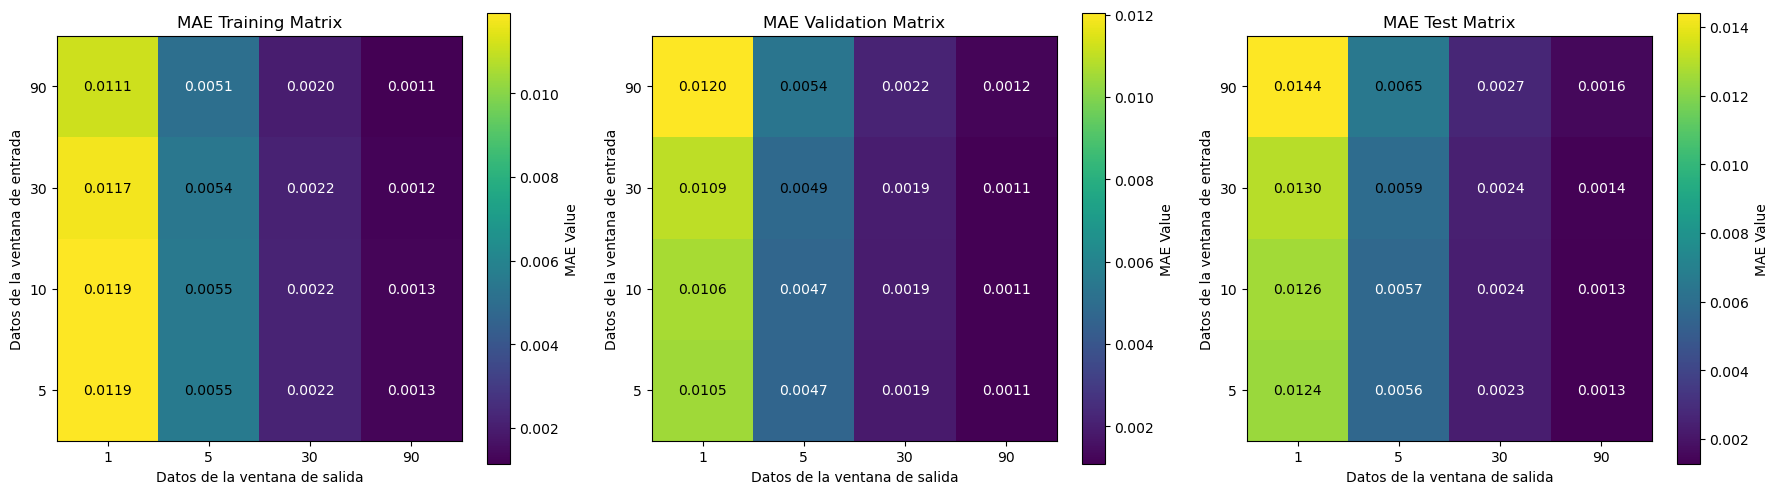

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [mae_train_matrix, mae_val_matrix, mae_test_matrix]
titles = ['MAE Training Matrix', 'MAE Validation Matrix', 'MAE Test Matrix']

for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', origin='lower')
    
    ax.set_xlabel('Datos de la ventana de salida')
    ax.set_ylabel('Datos de la ventana de entrada')
    ax.set_title(titles[i])
    
    ax.set_xticks(np.arange(len(ventanas_salida)))
    ax.set_xticklabels(ventanas_salida)
    
    ax.set_yticks(np.arange(len(ventanas_entrada)))
    ax.set_yticklabels(ventanas_entrada)

    for y in range(matrices[i].shape[0]):
        for x in range(matrices[i].shape[1]):
            value = matrices[i][y, x]
            ax.text(x, y, f"{value:.4f}",
                    ha='center', va='center',
                    color='black' if value > np.mean(matrices[i]) else 'white')
    
    fig.colorbar(im, ax=ax, label='MAE Value')

plt.tight_layout()
plt.show()

## 3. Entrenamiento de modelos de Deep Learning

In [38]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import LSTM, GRU
from tensorflow.keras.layers import MaxPooling1D, Convolution1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dropout, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from keras import regularizers

### 3.1 Modelos de capas densas (NN)

#### 3.1.1 Modelos con 5 datos de entrada

##### 3.1.1.1. Modelo con 1 dato de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a un día vista (y).

In [ ]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_reg[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test[(5,1)]

In [75]:
num_samples_train_5_1 = train_data_5_1.shape[0]
num_samples_val_5_1 = val_data_5_1.shape[0]
num_samples_test_5_1 = test_data_5_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_1 = train_data_5_1.reshape(num_samples_train_5_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_1 = val_data_5_1.reshape(num_samples_val_5_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_1 = test_data_5_1.reshape(num_samples_test_5_1, -1)

El modelo consta de una capa densa de 150 neuronas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [148]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_1 = Sequential()
model_NN_5_1.add(Dense(150, activation='relu', input_dim=(X_train_flat_5_1.shape[1])))
#model_NN_5_1.add(Dense(64, activation='relu'))
 
# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [149]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_1 = model_NN_5_1.fit(X_train_flat_5_1, train_target_5_1, validation_data=(X_val_flat_5_1, val_target_5_1), epochs=40)

Epoch 1/40


342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2097 - val_loss: 0.0832
Epoch 2/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0632 - val_loss: 0.0287
Epoch 3/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0220 - val_loss: 0.0129
Epoch 4/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0141 - val_loss: 0.0117
Epoch 5/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0136 - val_loss: 0.0117
Epoch 6/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0133 - val_loss: 0.0114
Epoch 7/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0132 - val_loss: 0.0112
Epoch 8/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - val_loss: 0.0110
Epoch 9/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0128 - val_loss: 0.0110
Epoch 10/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0126 - val_loss: 0.0109
Epoch 11/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0124 - val_loss: 0.0109
Epoch 12/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.

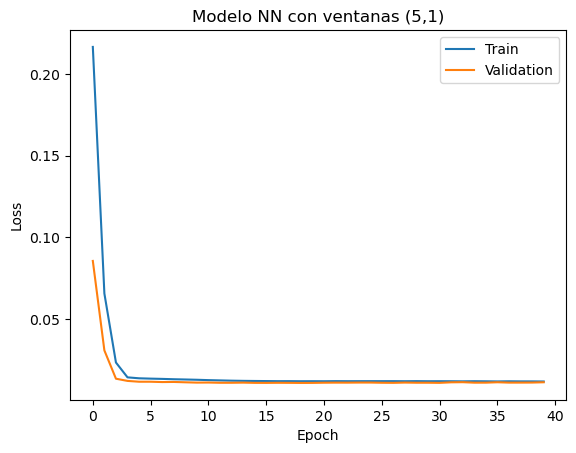

In [131]:
plt.plot(hist_NN_5_1.history['loss'])
plt.plot(hist_NN_5_1.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (5,1)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.1.2. Modelo con 5 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a cinco días vista (y).

In [132]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_reg[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test[(5,5)]

In [133]:
num_samples_train_5_5 = train_data_5_5.shape[0]
num_samples_val_5_5 = val_data_5_5.shape[0]
num_samples_test_5_5 = test_data_5_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_5 = train_data_5_5.reshape(num_samples_train_5_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_5 = val_data_5_5.reshape(num_samples_val_5_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_5 = test_data_5_5.reshape(num_samples_test_5_5, -1)

El modelo consta de una capa densa de entrada de 150 neuronas, dos capas ocultas de 128 y 64 neuronas y la capa de salida que predice los retornos de los 23 activos a cinco días vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [171]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_5 = Sequential()
model_NN_5_5.add(Dense(150, activation='relu', input_dim=(X_train_flat_5_5.shape[1])))
model_NN_5_5.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
model_NN_5_5.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [172]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_5 = model_NN_5_5.fit(X_train_flat_5_5, train_target_5_5, validation_data=(X_val_flat_5_5, val_target_5_5), epochs=40)

Epoch 1/40


342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0968 - val_loss: 0.0101
Epoch 2/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0076 - val_loss: 0.0049
Epoch 3/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0058 - val_loss: 0.0048
Epoch 4/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 6/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 7/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 8/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 9/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 10/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 11/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 12/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

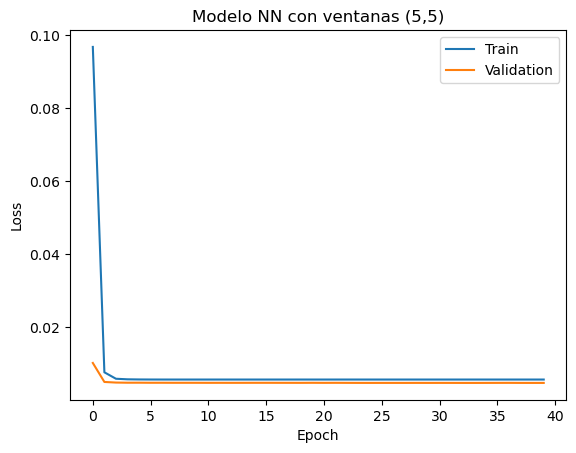

In [269]:
plt.plot(hist_NN_5_5.history['loss'])
plt.plot(hist_NN_5_5.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (5,5)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.1.3. Modelo con 30 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a treinta días vista (y).

In [174]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_reg[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test[(5,30)]

In [175]:
num_samples_train_5_30 = train_data_5_30.shape[0]
num_samples_val_5_30 = val_data_5_30.shape[0]
num_samples_test_5_30 = test_data_5_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_30 = train_data_5_30.reshape(num_samples_train_5_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_30 = val_data_5_30.reshape(num_samples_val_5_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_30 = test_data_5_30.reshape(num_samples_test_5_30, -1)

El modelo consta de una capa densa de entrada de 150 neuronas, una capa oculta de 128 y la capa de salida que predice los retornos de los 23 activos a treinta días vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [186]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_30 = Sequential()
model_NN_5_30.add(Dense(150, activation='relu', input_dim=(X_train_flat_5_30.shape[1])))
model_NN_5_30.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_5_30.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [187]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_30 = model_NN_5_30.fit(X_train_flat_5_30, train_target_5_30, validation_data=(X_val_flat_5_30, val_target_5_30), epochs=40)

Epoch 1/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2271 - val_loss: 0.1108
Epoch 2/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0790 - val_loss: 0.0275
Epoch 3/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0181 - val_loss: 0.0062
Epoch 4/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0060 - val_loss: 0.0034
Epoch 5/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 6/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0029 - val_loss: 0.0024
Epoch 7/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 8/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 9/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 11/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 12/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/ste

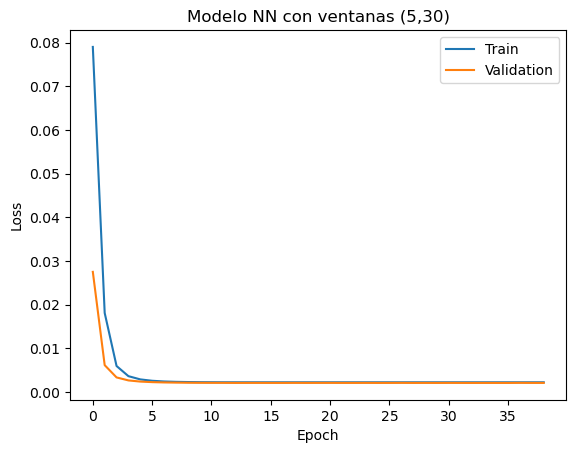

In [268]:
plt.plot(hist_NN_5_30.history['loss'][1:])
plt.plot(hist_NN_5_30.history['val_loss'][1:])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (5,30)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.1.4. Modelo con 90 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a noventa días vista (y).

In [190]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_reg[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test[(5,90)]

In [191]:
num_samples_train_5_90 = train_data_5_90.shape[0]
num_samples_val_5_90 = val_data_5_90.shape[0]
num_samples_test_5_90 = test_data_5_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_5_90 = train_data_5_90.reshape(num_samples_train_5_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_5_90 = val_data_5_90.reshape(num_samples_val_5_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_5_90 = test_data_5_90.reshape(num_samples_test_5_90, -1)

El modelo consta de una capa densa de entrada de 150 neuronas, dos capas ocultas de 128 y 64 neuronas y la capa de salida que predice los retornos de los 23 activos a noventa días vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_5_90 = Sequential()
model_NN_5_90.add(Dense(150, activation='relu', input_dim=(X_train_flat_5_90.shape[1])))
model_NN_5_90.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model_NN_5_90.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [201]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_5_90 = model_NN_5_90.fit(X_train_flat_5_90, train_target_5_90, validation_data=(X_val_flat_5_90, val_target_5_90), epochs=40)

Epoch 1/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2471 - val_loss: 0.1539
Epoch 2/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1403 - val_loss: 0.1264
Epoch 3/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1135 - val_loss: 0.1001
Epoch 4/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0879 - val_loss: 0.0756
Epoch 5/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0650 - val_loss: 0.0546
Epoch 6/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0460 - val_loss: 0.0377
Epoch 7/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0311 - val_loss: 0.0249
Epoch 8/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0202 - val_loss: 0.0157
Epoch 9/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0126 - val_loss: 0.0096
Epoch 10/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0077 - val_loss: 0.0057
Epoch 11/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0046 - val_loss: 0.0034
Epoch 12/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

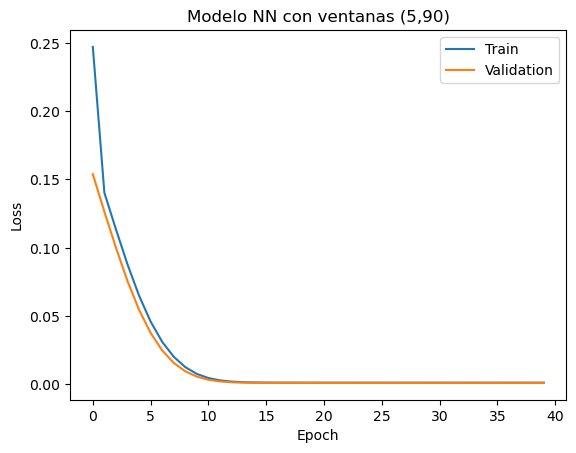

In [267]:
plt.plot(hist_NN_5_90.history['loss'])
plt.plot(hist_NN_5_90.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (5,90)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

#### 3.1.2 Modelos con 10 datos de entrada

##### 3.1.2.1. Modelo con 1 dato de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a un día vista (y).

In [203]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_reg[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test[(10,1)]

In [204]:
num_samples_train_10_1 = train_data_10_1.shape[0]
num_samples_val_10_1 = val_data_10_1.shape[0]
num_samples_test_10_1 = test_data_10_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_1 = train_data_10_1.reshape(num_samples_train_10_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_1 = val_data_10_1.reshape(num_samples_val_10_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_1 = test_data_10_1.reshape(num_samples_test_10_1, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [225]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_1 = Sequential()
model_NN_10_1.add(Dense(150, activation='relu', input_dim=(X_train_flat_10_1.shape[1])))
model_NN_10_1.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_1.add(Dropout(0.2))
model_NN_10_1.add(Dense(64, activation='relu'))
#model_NN_10_1.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [226]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_1 = model_NN_10_1.fit(X_train_flat_10_1, train_target_10_1, validation_data=(X_val_flat_10_1, val_target_10_1), epochs=40)

Epoch 1/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1316 - val_loss: 0.0233
Epoch 2/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0157 - val_loss: 0.0109
Epoch 3/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0123 - val_loss: 0.0106
Epoch 4/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 6/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 7/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 8/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 9/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 11/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 12/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

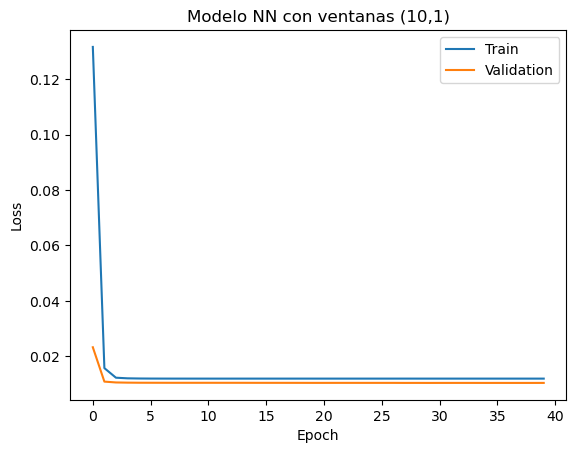

In [266]:
plt.plot(hist_NN_10_1.history['loss'])
plt.plot(hist_NN_10_1.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (10,1)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.2.2. Modelo con 5 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a cinco días vista (y).

In [228]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_reg[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test[(10,5)]

In [229]:
num_samples_train_10_5 = train_data_10_5.shape[0]
num_samples_val_10_5 = val_data_10_5.shape[0]
num_samples_test_10_5 = test_data_10_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_5 = train_data_10_5.reshape(num_samples_train_10_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_5 = val_data_10_5.reshape(num_samples_val_10_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_5 = test_data_10_5.reshape(num_samples_test_10_5, -1)

El modelo consta de una capa densa de 150 neuronas, dos capas ocultas densas de 128 y 64 neuronas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [230]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_5 = Sequential()
model_NN_10_5.add(Dense(150, activation='relu', input_dim=(X_train_flat_10_5.shape[1])))
model_NN_10_5.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_5.add(Dropout(0.2))
model_NN_10_5.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [231]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_5 = model_NN_10_5.fit(X_train_flat_10_5, train_target_10_5, validation_data=(X_val_flat_10_5, val_target_10_5), epochs=40)

Epoch 1/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.1143 - val_loss: 0.0128
Epoch 2/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0081 - val_loss: 0.0050
Epoch 3/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 4/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 5/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 6/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 7/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 8/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 9/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 10/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 11/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 12/40
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/ste

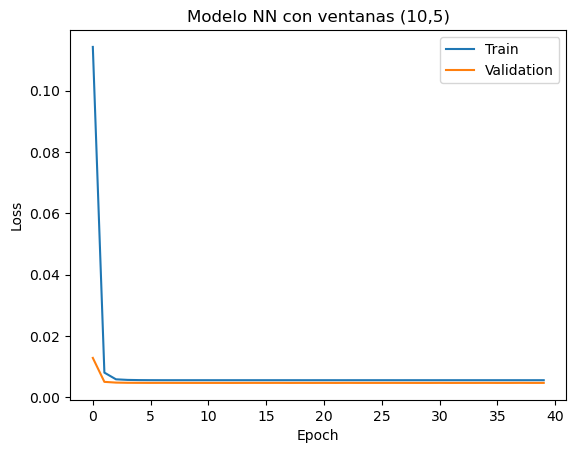

In [265]:
plt.plot(hist_NN_10_5.history['loss'])
plt.plot(hist_NN_10_5.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (10,5)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.2.3. Modelo con 30 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a treinta días vista (y).

In [233]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_reg[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test[(10,30)]

In [234]:
num_samples_train_10_30 = train_data_10_30.shape[0]
num_samples_val_10_30 = val_data_10_30.shape[0]
num_samples_test_10_30 = test_data_10_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_30 = train_data_10_30.reshape(num_samples_train_10_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_30 = val_data_10_30.reshape(num_samples_val_10_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_30 = test_data_10_30.reshape(num_samples_test_10_30, -1)

El modelo consta de una capa densa de entrada de 150 neuronas, una capa oculta de 128 y la capa de salida que predice los retornos de los 23 activos a treinta días vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [239]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_30 = Sequential()
model_NN_10_30.add(Dense(150, activation='relu', input_dim=(X_train_flat_10_30.shape[1])))
model_NN_10_30.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_30.add(Dropout(0.2))
model_NN_10_30.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [240]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_30 = model_NN_10_30.fit(X_train_flat_10_30, train_target_10_30, validation_data=(X_val_flat_10_30, val_target_10_30), epochs=40)

Epoch 1/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1487 - val_loss: 0.0359
Epoch 2/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0113 - val_loss: 0.0026
Epoch 3/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 4/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 5/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 7/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 9/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 10/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 11/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 12/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/

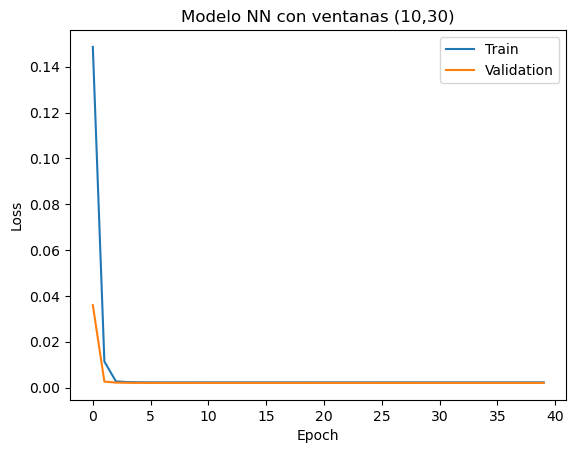

In [264]:
plt.plot(hist_NN_10_30.history['loss'])
plt.plot(hist_NN_10_30.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (10,30)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.2.4. Modelo con 90 datos de salida

Seleccionamos los datos normalizados (X) y la media de los retornos esperados a noventa días vista (y).

In [242]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_reg[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test[(10,90)]

In [243]:
num_samples_train_10_90 = train_data_10_90.shape[0]
num_samples_val_10_90 = val_data_10_90.shape[0]
num_samples_test_10_90 = test_data_10_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_10_90 = train_data_10_90.reshape(num_samples_train_10_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_10_90 = val_data_10_90.reshape(num_samples_val_10_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_10_90 = test_data_10_90.reshape(num_samples_test_10_90, -1)

El modelo consta de una capa densa de entrada de 150 neuronas, dos capas ocultas de 128 y 64 neuronas y la capa de salida que predice los retornos de los 23 activos a noventa días vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [244]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_10_90 = Sequential()
model_NN_10_90.add(Dense(150, activation='relu', input_dim=(X_train_flat_10_90.shape[1])))
model_NN_10_90.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_10_90.add(Dropout(0.2))
model_NN_10_90.add(Dense(64, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [245]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_10_90 = model_NN_10_90.fit(X_train_flat_10_90, train_target_10_90, validation_data=(X_val_flat_10_90, val_target_10_90), epochs=40)

Epoch 1/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.1097 - val_loss: 0.0093
Epoch 2/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0037 - val_loss: 0.0016
Epoch 3/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 4/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

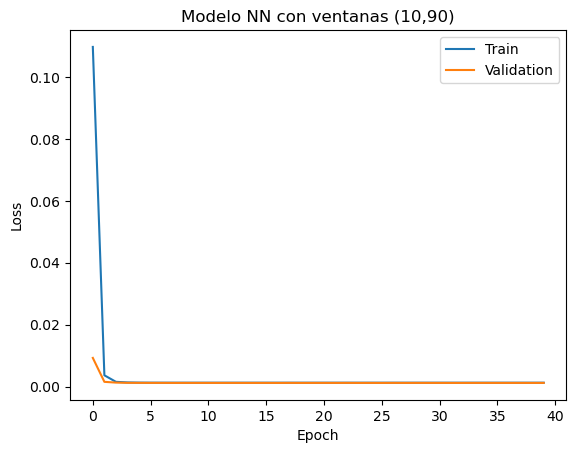

In [263]:
plt.plot(hist_NN_10_90.history['loss'])
plt.plot(hist_NN_10_90.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (10,90)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

#### 3.1.3 Modelos con 30 datos de entrada

##### 3.1.3.1. Modelo con 1 dato de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a un día vista (y).

In [251]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_reg[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test[(30,1)]

In [252]:
num_samples_train_30_1 = train_data_30_1.shape[0]
num_samples_val_30_1 = val_data_30_1.shape[0]
num_samples_test_30_1 = test_data_30_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_1 = train_data_30_1.reshape(num_samples_train_30_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_1 = val_data_30_1.reshape(num_samples_val_30_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_1 = test_data_30_1.reshape(num_samples_test_30_1, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [253]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_1 = Sequential()
model_NN_30_1.add(Dense(150, activation='relu', input_dim=(X_train_flat_30_1.shape[1])))
model_NN_30_1.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_1.add(Dropout(0.2))
model_NN_30_1.add(Dense(64, activation='relu'))
#model_NN_30_1.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [254]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_1 = model_NN_30_1.fit(X_train_flat_30_1, train_target_30_1, validation_data=(X_val_flat_30_1, val_target_30_1), epochs=40)

Epoch 1/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.1460 - val_loss: 0.0211
Epoch 2/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0151 - val_loss: 0.0111
Epoch 3/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0122 - val_loss: 0.0107
Epoch 4/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 5/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 6/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 7/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 8/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 9/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 10/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 11/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 12/40
341/341 ━━━━━━━━━━━━━━━━━━━━

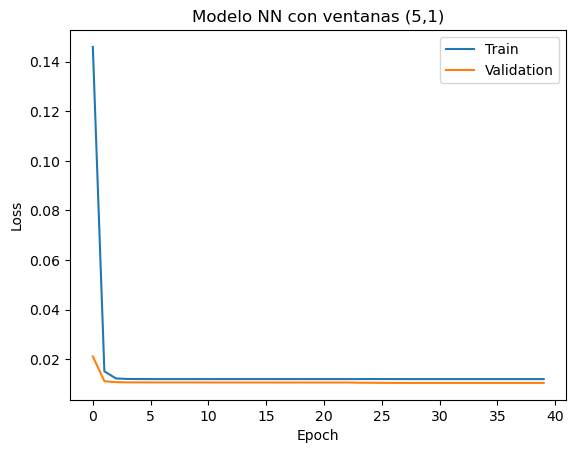

In [ ]:
plt.plot(hist_NN_30_1.history['loss'])
plt.plot(hist_NN_30_1.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (30,1)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.3.2. Modelo con 5 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a cinco días vista (y).

In [256]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_reg[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test[(30,5)]

In [257]:
num_samples_train_30_5 = train_data_30_5.shape[0]
num_samples_val_30_5 = val_data_30_5.shape[0]
num_samples_test_30_5 = test_data_30_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_5 = train_data_30_5.reshape(num_samples_train_30_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_5 = val_data_30_5.reshape(num_samples_val_30_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_5 = test_data_30_5.reshape(num_samples_test_30_5, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [260]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_5 = Sequential()
model_NN_30_5.add(Dense(150, activation='relu', input_dim=(X_train_flat_30_5.shape[1])))
model_NN_30_5.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_5.add(Dropout(0.2))
model_NN_30_5.add(Dense(64, activation='relu'))
#model_NN_30_5.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [261]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_5 = model_NN_30_5.fit(X_train_flat_30_5, train_target_30_5, validation_data=(X_val_flat_30_5, val_target_30_5), epochs=40)

Epoch 1/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.1315 - val_loss: 0.0091
Epoch 2/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0072 - val_loss: 0.0052
Epoch 3/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0058 - val_loss: 0.0050
Epoch 4/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 5/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 6/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 7/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 8/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 9/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 10/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 11/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 12/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 

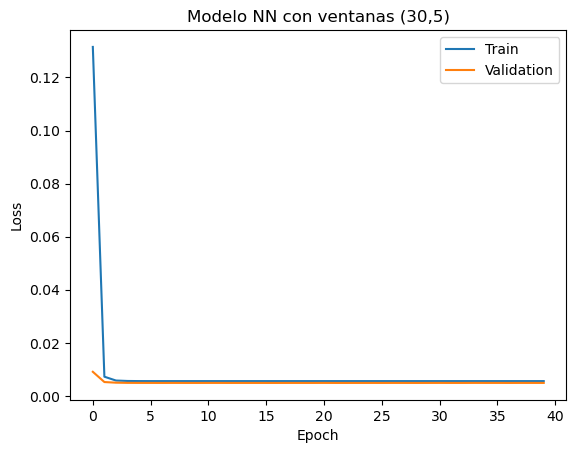

In [262]:
plt.plot(hist_NN_30_5.history['loss'])
plt.plot(hist_NN_30_5.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (30,5)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.3.3. Modelo con 30 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a treinta días vista (y).

In [270]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_reg[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test[(30,30)]

In [271]:
num_samples_train_30_30 = train_data_30_30.shape[0]
num_samples_val_30_30 = val_data_30_30.shape[0]
num_samples_test_30_30 = test_data_30_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_30 = train_data_30_30.reshape(num_samples_train_30_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_30 = val_data_30_30.reshape(num_samples_val_30_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_30 = test_data_30_30.reshape(num_samples_test_30_30, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [272]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_30 = Sequential()
model_NN_30_30.add(Dense(150, activation='relu', input_dim=(X_train_flat_30_30.shape[1])))
model_NN_30_30.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_30.add(Dropout(0.2))
model_NN_30_30.add(Dense(64, activation='relu'))
#model_NN_30_30.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [273]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_30 = model_NN_30_30.fit(X_train_flat_30_30, train_target_30_30, validation_data=(X_val_flat_30_30, val_target_30_30), epochs=40)

Epoch 1/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.1349 - val_loss: 0.0128
Epoch 2/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 3/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 4/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 5/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 6/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 7/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 9/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 12/40
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/ste

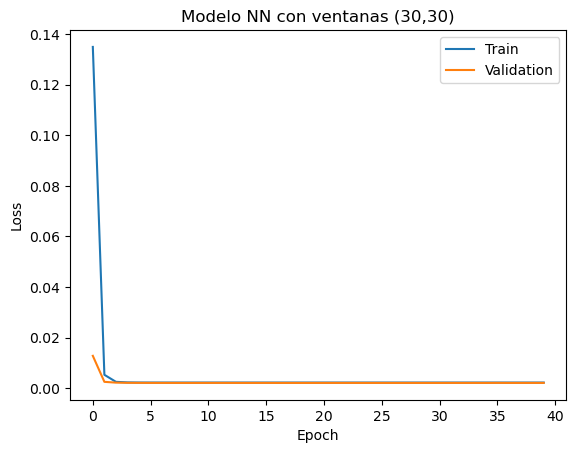

In [274]:
plt.plot(hist_NN_30_30.history['loss'])
plt.plot(hist_NN_30_30.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (30,30)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.3.4. Modelo con 90 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a noventa días vista (y).

In [275]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_reg[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test[(30,90)]

In [276]:
num_samples_train_30_90 = train_data_30_90.shape[0]
num_samples_val_30_90 = val_data_30_90.shape[0]
num_samples_test_30_90 = test_data_30_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_30_90 = train_data_30_90.reshape(num_samples_train_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_30_90 = val_data_30_90.reshape(num_samples_val_30_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_30_90 = test_data_30_90.reshape(num_samples_test_30_90, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [277]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_30_90 = Sequential()
model_NN_30_90.add(Dense(150, activation='relu', input_dim=(X_train_flat_30_90.shape[1])))
model_NN_30_90.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_30_90.add(Dropout(0.2))
model_NN_30_90.add(Dense(64, activation='relu'))
#model_NN_30_90.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [278]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_30_90 = model_NN_30_90.fit(X_train_flat_30_90, train_target_30_90, validation_data=(X_val_flat_30_90, val_target_30_90), epochs=40)

Epoch 1/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1233 - val_loss: 0.0109
Epoch 2/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 3/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 4/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 5/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 6/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 12/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

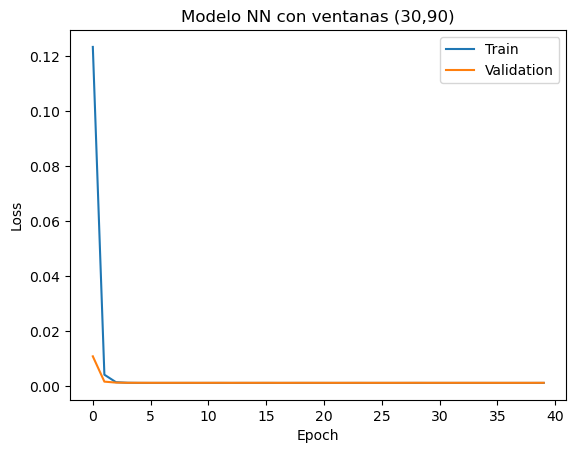

In [279]:
plt.plot(hist_NN_30_90.history['loss'])
plt.plot(hist_NN_30_90.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (30,90)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

#### 3.1.4 Modelos con 90 datos de entrada

##### 3.1.4.1. Modelo con 1 dato de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a un día vista (y).

In [280]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_reg[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test[(90,1)]

In [281]:
num_samples_train_90_1 = train_data_90_1.shape[0]
num_samples_val_90_1 = val_data_90_1.shape[0]
num_samples_test_90_1 = test_data_90_1.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_1 = train_data_90_1.reshape(num_samples_train_90_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_1 = val_data_90_1.reshape(num_samples_val_90_1, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_1 = test_data_90_1.reshape(num_samples_test_90_1, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [282]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_1 = Sequential()
model_NN_90_1.add(Dense(150, activation='relu', input_dim=(X_train_flat_90_1.shape[1])))
model_NN_90_1.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_90_1.add(Dropout(0.2))
model_NN_90_1.add(Dense(64, activation='relu'))
#model_NN_90_1.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [283]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_1 = model_NN_90_1.fit(X_train_flat_90_1, train_target_90_1, validation_data=(X_val_flat_90_1, val_target_90_1), epochs=40)

Epoch 1/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1832 - val_loss: 0.0345
Epoch 2/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0173 - val_loss: 0.0116
Epoch 3/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0122 - val_loss: 0.0112
Epoch 4/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0111
Epoch 5/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0120 - val_loss: 0.0111
Epoch 6/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0111
Epoch 7/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 8/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 9/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 10/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 11/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 12/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/ste

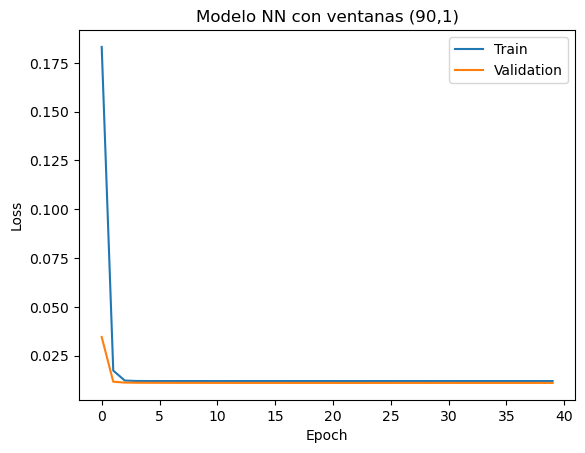

In [284]:
plt.plot(hist_NN_90_1.history['loss'])
plt.plot(hist_NN_90_1.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (90,1)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.4.2. Modelo con 5 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a cinco días vista (y).

In [285]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_reg[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test[(90,5)]

In [286]:
num_samples_train_90_5 = train_data_90_5.shape[0]
num_samples_val_90_5 = val_data_90_5.shape[0]
num_samples_test_90_5 = test_data_90_5.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_5 = train_data_90_5.reshape(num_samples_train_90_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_5 = val_data_90_5.reshape(num_samples_val_90_5, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_5 = test_data_90_5.reshape(num_samples_test_90_5, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [287]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_5 = Sequential()
model_NN_90_5.add(Dense(150, activation='relu', input_dim=(X_train_flat_90_5.shape[1])))
model_NN_90_5.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_90_5.add(Dropout(0.2))
model_NN_90_5.add(Dense(64, activation='relu'))
#model_NN_90_5.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [288]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_5 = model_NN_90_5.fit(X_train_flat_90_5, train_target_90_5, validation_data=(X_val_flat_90_5, val_target_90_5), epochs=40)

Epoch 1/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.1477 - val_loss: 0.0172
Epoch 2/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0087 - val_loss: 0.0056
Epoch 3/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0057 - val_loss: 0.0053
Epoch 4/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 5/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 6/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 7/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 8/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 9/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 10/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 11/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0053
Epoch 12/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

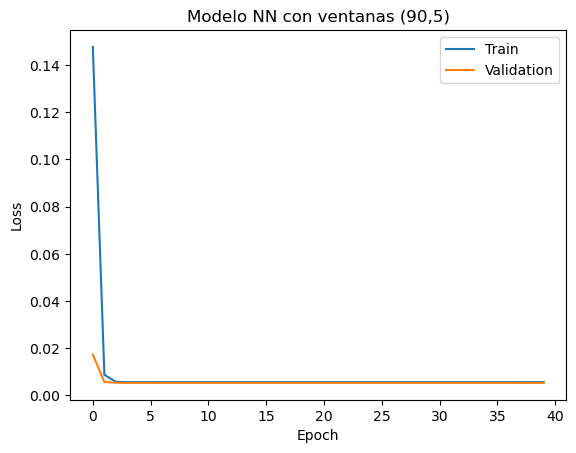

In [291]:
plt.plot(hist_NN_90_5.history['loss'])
plt.plot(hist_NN_90_5.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (90,5)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.4.3. Modelo con 30 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a treinta días vista (y).

In [292]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_reg[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test[(90,30)]

In [293]:
num_samples_train_90_30 = train_data_90_30.shape[0]
num_samples_val_90_30 = val_data_90_30.shape[0]
num_samples_test_90_30 = test_data_90_30.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_30 = train_data_90_30.reshape(num_samples_train_90_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_30 = val_data_90_30.reshape(num_samples_val_90_30, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_30 = test_data_90_30.reshape(num_samples_test_90_30, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [294]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_30 = Sequential()
model_NN_90_30.add(Dense(150, activation='relu', input_dim=(X_train_flat_90_30.shape[1])))
model_NN_90_30.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_90_30.add(Dropout(0.2))
model_NN_90_30.add(Dense(64, activation='relu'))
#model_NN_90_30.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [295]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_30 = model_NN_90_30.fit(X_train_flat_90_30, train_target_90_30, validation_data=(X_val_flat_90_30, val_target_90_30), epochs=40)

Epoch 1/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - loss: 0.1194 - val_loss: 0.0076
Epoch 2/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 3/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 4/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 5/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 6/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 7/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 8/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 9/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 10/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 11/40
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 12/40
339/339 ━━━━━━━━━━━━━━━━━━━━

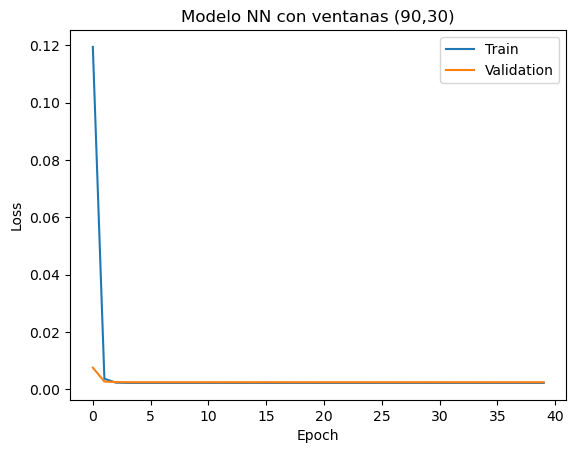

In [296]:
plt.plot(hist_NN_90_30.history['loss'])
plt.plot(hist_NN_90_30.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (90,30)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

##### 3.1.4.4. Modelo con 90 datos de salida

Seleccionamos los datos normalizados (X) y los retornos esperados a noventa días vista (y).

In [297]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_reg[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test[(90,90)]

In [298]:
num_samples_train_90_90 = train_data_90_90.shape[0]
num_samples_val_90_90 = val_data_90_90.shape[0]
num_samples_test_90_90 = test_data_90_90.shape[0]

# Flatten X_train_seq to (num_samples, input_window_size * num_features)
X_train_flat_90_90 = train_data_90_90.reshape(num_samples_train_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_val_flat_90_90 = val_data_90_90.reshape(num_samples_val_90_90, -1)

# Flatten X_test_seq to (num_samples, input_window_size * num_features)
X_test_flat_90_90 = test_data_90_90.reshape(num_samples_test_90_90, -1)

El modelo consta de una capa de entrada densa de 150 neuronas, dos capas ocultas densas de 128 y 64 capas y la capa de salida que predice los retornos de los 23 activos a un día vista.

Se han probado modelos con más capas ocultas pero la conclusión es que la red neuronal ofrece los mismos resultados que una regresión lineal clásica.

In [299]:
# Modelo con 5 datos de entrada y uno de salida
model_NN_90_90 = Sequential()
model_NN_90_90.add(Dense(150, activation='relu', input_dim=(X_train_flat_90_90.shape[1])))
model_NN_90_90.add(Dense(128, activation='relu'))#, kernel_regularizer=regularizers.l2(0.001)))
#model_NN_90_90.add(Dropout(0.2))
model_NN_90_90.add(Dense(64, activation='relu'))
#model_NN_90_90.add(Dense(32, activation='relu'))

# 3. Capa de salida para los 23 activos (sin escalar, valores reales de retornos)
model_NN_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_NN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

In [300]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_NN_90_90 = model_NN_90_90.fit(X_train_flat_90_90, train_target_90_90, validation_data=(X_val_flat_90_90, val_target_90_90), epochs=40)

Epoch 1/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.1003 - val_loss: 0.0048
Epoch 2/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 4/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 5/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 6/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 7/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 9/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 10/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 11/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 12/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 4

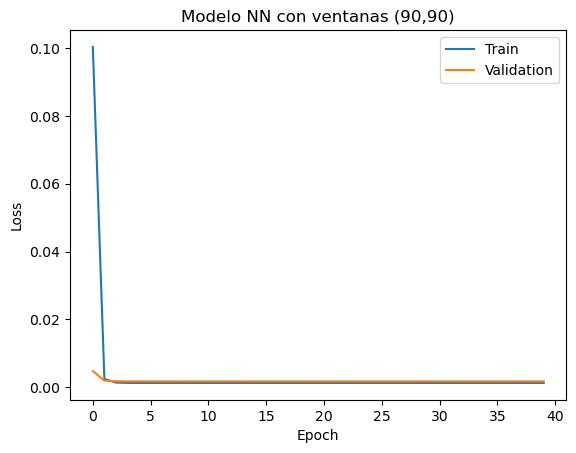

In [301]:
plt.plot(hist_NN_90_90.history['loss'])
plt.plot(hist_NN_90_90.history['val_loss'])
#plt.axhline(0.012)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Modelo NN con ventanas (90,90)')
plt.legend(['Train', 'Validation'])#, 'Regresión Lineal'])
plt.show()

#### 3.1.5 Conclusiones modelos de capas densas (NN)

En general, los modelos que usan solamente capas densas no mejoran los modelos de regresiones lineales.

### 3.2 Modelos de capas recurrentes (RNN)

#### 3.2.1 Modelos con 5 datos de entrada

##### 3.2.1.1. Modelo con 1 dato de salida

In [12]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_reg[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test[(5,1)]

In [35]:
model_RNN_5_1 = Sequential()

model_RNN_5_1.add(LSTM(64, input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
#model_RNN_5_1.add(Dropout(0.3))
#model_RNN_5_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_1.add(LSTM(32))
model_RNN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_RNN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001))

model_RNN_5_1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_1 = model_RNN_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=30)

Epoch 1/30


342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0281 - val_loss: 0.0158
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0167 - val_loss: 0.0127
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0144 - val_loss: 0.0117
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0136 - val_loss: 0.0113
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0131 - val_loss: 0.0111
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0128 - val_loss: 0.0109
Epoch 7/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0126 - val_loss: 0.0108
Epoch 8/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0125 - val_loss: 0.0107
Epoch 9/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0124 - val_loss: 0.0107
Epoch 10/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0123 - val_loss: 0.0106
Epoch 11/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0122 - val_loss: 0.0106
Epoch 12/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/st

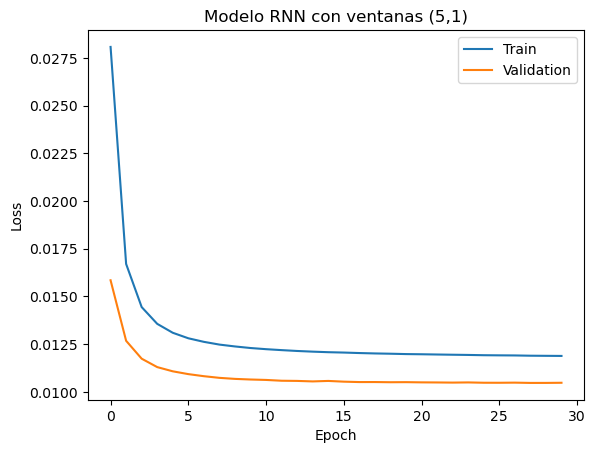

In [115]:
plt.plot(hist_RNN_5_1.history['loss'])
plt.plot(hist_RNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (5,1)')
plt.show()

##### 3.2.1.2. Modelo con 5 datos de salida

In [38]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_reg[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test[(5,5)]

In [43]:
model_RNN_5_5 = Sequential()

model_RNN_5_5.add(LSTM(64, input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_5.add(Dropout(0.3))
#model_RNN_5_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_5.add(LSTM(32))
model_RNN_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

model_RNN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_5.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_5 = model_RNN_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=100)

Epoch 1/100


342/342 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0104 - val_loss: 0.0048
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0058 - val_loss: 0.0048
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 9/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0055 - val_loss: 0.0047
Epoch 10/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 11/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 12/100
342/342 ━━━━━━━━━━━━━━━━━━━

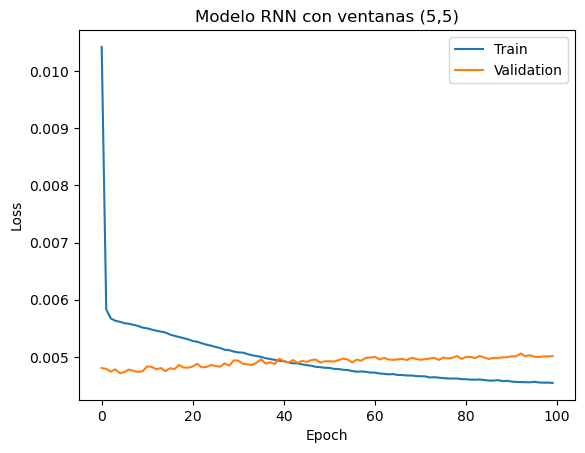

In [116]:
plt.plot(hist_RNN_5_5.history['loss'])
plt.plot(hist_RNN_5_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (5,5)')
plt.show()

##### 3.2.1.3. Modelo con 30 datos de salida

In [46]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_reg[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test[(5,30)]

In [47]:
model_RNN_5_30 = Sequential()

model_RNN_5_30.add(LSTM(64, input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_30.add(Dropout(0.3))
#model_RNN_5_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_30.add(LSTM(32))
model_RNN_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

model_RNN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_30 = model_RNN_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.0084 - val_loss: 0.0021
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━

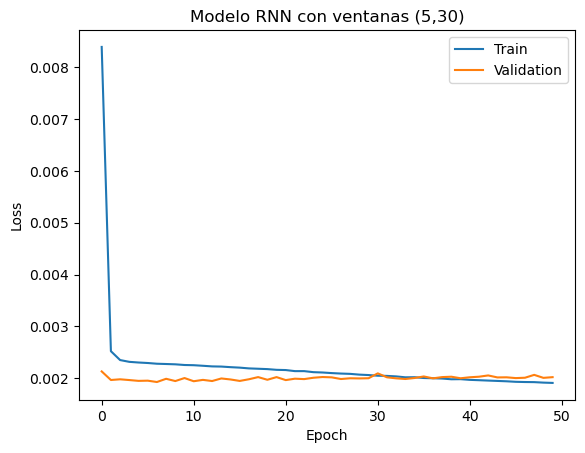

In [117]:
plt.plot(hist_RNN_5_30.history['loss'])
plt.plot(hist_RNN_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (5,30)')
plt.show()

##### 3.2.1.4. Modelo con 90 datos de salida

In [50]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_reg[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test[(5,90)]

In [51]:
model_RNN_5_90 = Sequential()

model_RNN_5_90.add(LSTM(64, input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_5_90.add(Dropout(0.3))
#model_RNN_5_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_5_90.add(LSTM(32))
model_RNN_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

model_RNN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_5_90.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 5, 64)          │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_5_90 = model_RNN_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - loss: 0.0081 - val_loss: 0.0014
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━

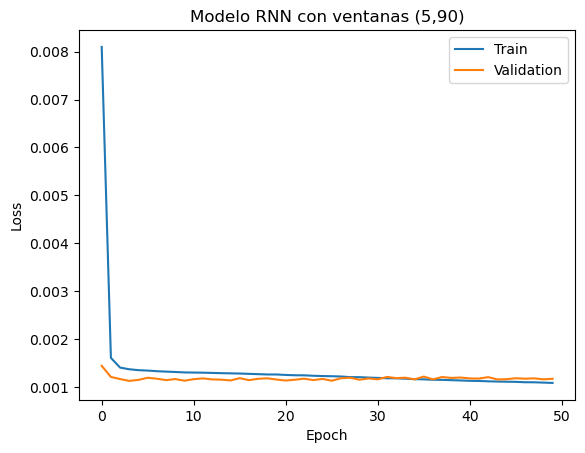

In [118]:
plt.plot(hist_RNN_5_90.history['loss'])
plt.plot(hist_RNN_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (5,90)')
plt.show()

#### 3.2.2 Modelos con 10 datos de entrada

##### 3.2.2.1. Modelo con 1 dato de salida

In [54]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_reg[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test[(10,1)]

In [55]:
model_RNN_10_1 = Sequential()

model_RNN_10_1.add(LSTM(64, input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_1.add(Dropout(0.3))
#model_RNN_10_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_1.add(LSTM(32))
model_RNN_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

model_RNN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_1.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_1 = model_RNN_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 0.0172 - val_loss: 0.0106
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0124 - val_loss: 0.0105
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━

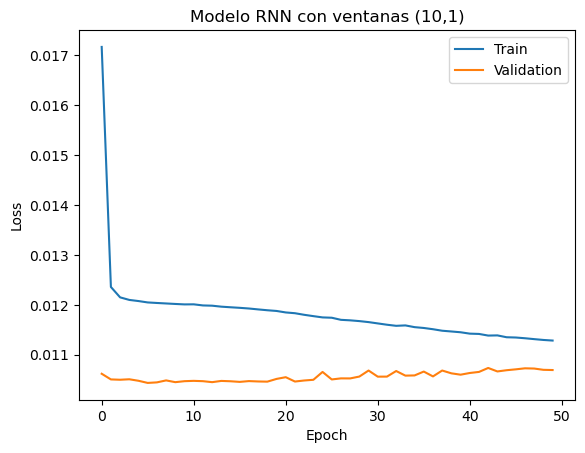

In [119]:
plt.plot(hist_RNN_10_1.history['loss'])
plt.plot(hist_RNN_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (10,1)')
plt.show()

##### 3.2.2.2. Modelo con 5 datos de salida

In [58]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_reg[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test[(10,5)]

In [59]:
model_RNN_10_5 = Sequential()

model_RNN_10_5.add(LSTM(64, input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_5.add(Dropout(0.3))
#model_RNN_10_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_5.add(LSTM(32))
model_RNN_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

model_RNN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_5.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_5 = model_RNN_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.0123 - val_loss: 0.0049
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━

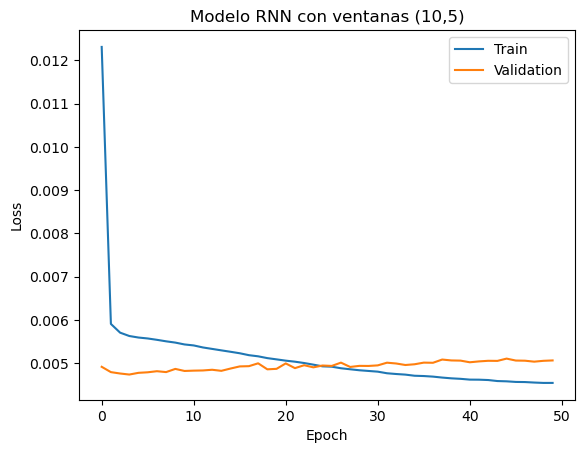

In [122]:
plt.plot(hist_RNN_10_5.history['loss'])
plt.plot(hist_RNN_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (10,5)')
plt.show()

##### 3.2.2.3. Modelo con 30 datos de salida

In [62]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_reg[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test[(10,30)]

In [63]:
model_RNN_10_30 = Sequential()

model_RNN_10_30.add(LSTM(64, input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_30.add(Dropout(0.3))
#model_RNN_10_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_30.add(LSTM(32))
model_RNN_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

model_RNN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_30 = model_RNN_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - loss: 0.0095 - val_loss: 0.0022
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━

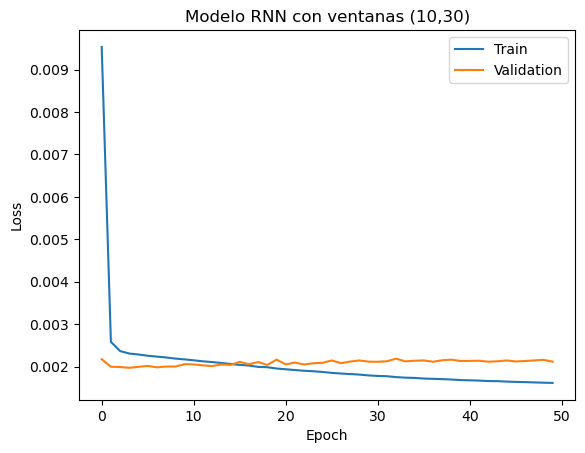

In [121]:
plt.plot(hist_RNN_10_30.history['loss'])
plt.plot(hist_RNN_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (10,30)')
plt.show()

##### 3.2.2.4. Modelo con 90 datos de salida

In [66]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_reg[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test[(10,90)]

In [67]:
model_RNN_10_90 = Sequential()

model_RNN_10_90.add(LSTM(64, input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_10_90.add(Dropout(0.3))
#model_RNN_10_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_10_90.add(LSTM(32))
model_RNN_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

model_RNN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_10_90.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 10, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_10_90 = model_RNN_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - loss: 0.0087 - val_loss: 0.0015
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━

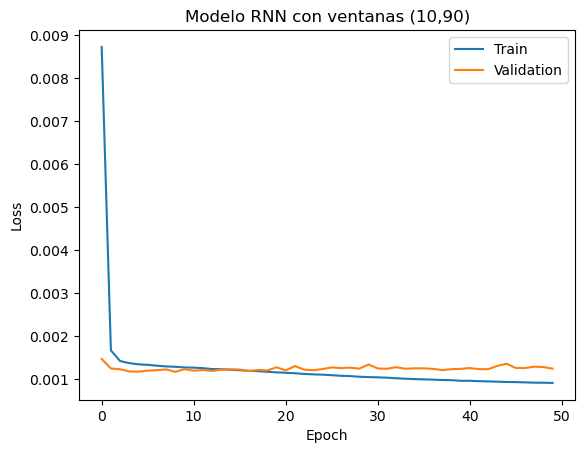

In [120]:
plt.plot(hist_RNN_10_90.history['loss'])
plt.plot(hist_RNN_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (10,90)')
plt.show()

#### 3.2.3 Modelos con 30 datos de entrada

##### 3.2.3.1. Modelo con 1 dato de salida

In [70]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_reg[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test[(30,1)]

In [71]:
model_RNN_30_1 = Sequential()

model_RNN_30_1.add(LSTM(64, input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_1.add(Dropout(0.3))
#model_RNN_30_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_1.add(LSTM(32))
model_RNN_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

model_RNN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_1.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_1 = model_RNN_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - loss: 0.0177 - val_loss: 0.0107
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0124 - val_loss: 0.0106
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.0122 - val_loss: 0.0106
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
341/341 ━━━━━━━━━━

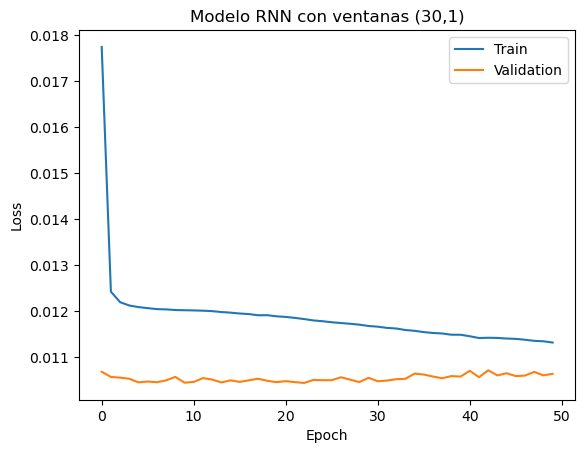

In [126]:
plt.plot(hist_RNN_30_1.history['loss'])
plt.plot(hist_RNN_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (30,1)')
plt.show()

##### 3.2.3.2. Modelo con 5 datos de salida

In [74]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_reg[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test[(30,5)]

In [75]:
model_RNN_30_5 = Sequential()

model_RNN_30_5.add(LSTM(64, input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_5.add(Dropout(0.3))
#model_RNN_30_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_5.add(LSTM(32))
model_RNN_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

model_RNN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_5.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_5 = model_RNN_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - loss: 0.0118 - val_loss: 0.0050
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 12/50
341/341 ━━━━━━━━━━

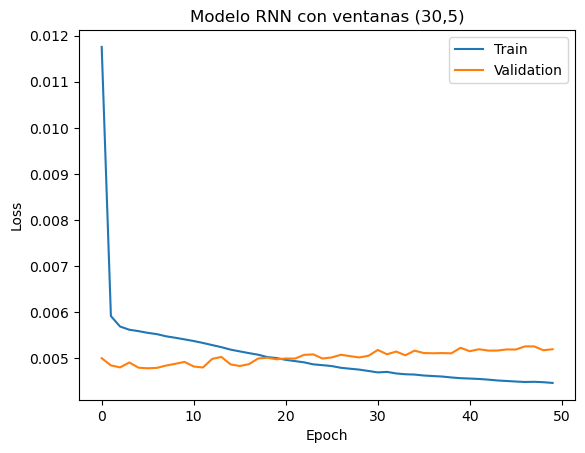

In [125]:
plt.plot(hist_RNN_30_5.history['loss'])
plt.plot(hist_RNN_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (30,5)')
plt.show()

##### 3.2.3.3. Modelo con 30 datos de salida

In [78]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_reg[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test[(30,30)]

In [79]:
model_RNN_30_30 = Sequential()

model_RNN_30_30.add(LSTM(64, input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_30.add(Dropout(0.3))
#model_RNN_30_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_30.add(LSTM(32))
model_RNN_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

model_RNN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_30.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_44 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_30 = model_RNN_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 0.0099 - val_loss: 0.0025
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 12/50
341/341 ━━━━━━━━━━

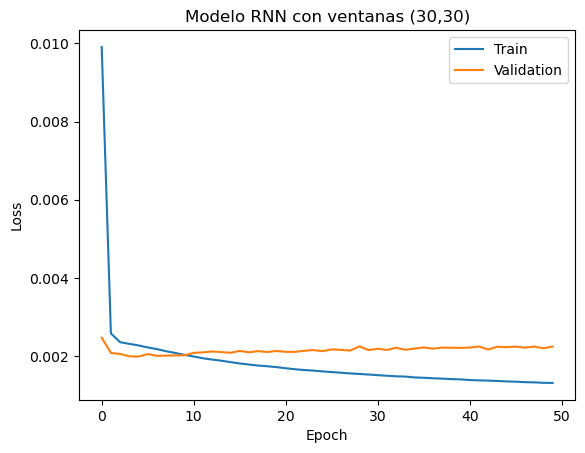

In [124]:
plt.plot(hist_RNN_30_30.history['loss'])
plt.plot(hist_RNN_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (30,30)')
plt.show()

##### 3.2.3.4. Modelo con 90 datos de salida

In [82]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_reg[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test[(30,90)]

In [83]:
model_RNN_30_90 = Sequential()

model_RNN_30_90.add(LSTM(64, input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_30_90.add(Dropout(0.3))
#model_RNN_30_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_30_90.add(LSTM(32))
model_RNN_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

model_RNN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_30_90.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_46 (LSTM)                  │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_30_90 = model_RNN_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=50)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - loss: 0.0096 - val_loss: 0.0016
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/50
339/339 ━━━━━━━━━━

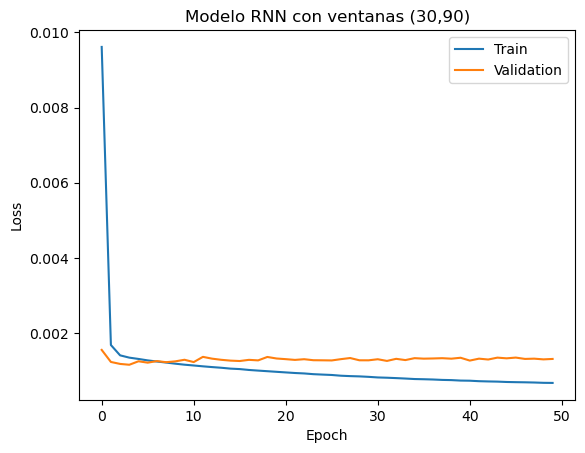

In [123]:
plt.plot(hist_RNN_30_90.history['loss'])
plt.plot(hist_RNN_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (30,90)')
plt.show()

#### 3.2.4 Modelos con 90 datos de entrada

##### 3.2.4.1. Modelo con 1 dato de salida

In [86]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_reg[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test[(90,1)]

In [87]:
model_RNN_90_1 = Sequential()

model_RNN_90_1.add(LSTM(64, input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_1.add(Dropout(0.3))
#model_RNN_90_1.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_1.add(LSTM(32))
model_RNN_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

model_RNN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_1.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_1 = model_RNN_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - loss: 0.0173 - val_loss: 0.0107
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.0124 - val_loss: 0.0107
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 12/50
340/340

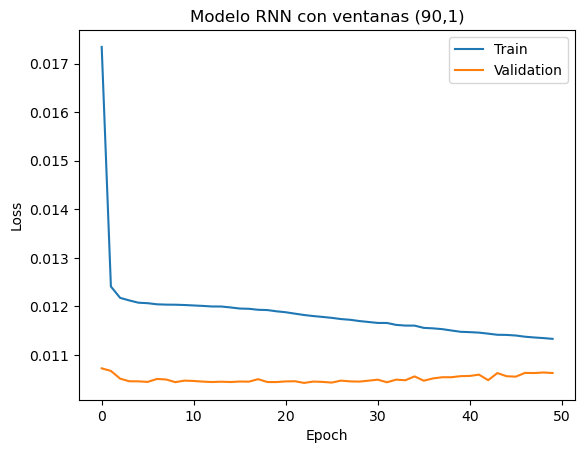

In [130]:
plt.plot(hist_RNN_90_1.history['loss'])
plt.plot(hist_RNN_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (90,1)')
plt.show()

##### 3.2.4.2. Modelo con 5 datos de salida

In [90]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_reg[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test[(90,5)]

In [91]:
model_RNN_90_5 = Sequential()

model_RNN_90_5.add(LSTM(64, input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_5.add(Dropout(0.3))
#model_RNN_90_5.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_5.add(LSTM(32))
model_RNN_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

model_RNN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_5.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_50 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_5 = model_RNN_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 49s 118ms/step - loss: 0.0124 - val_loss: 0.0050
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 12/50
340/340

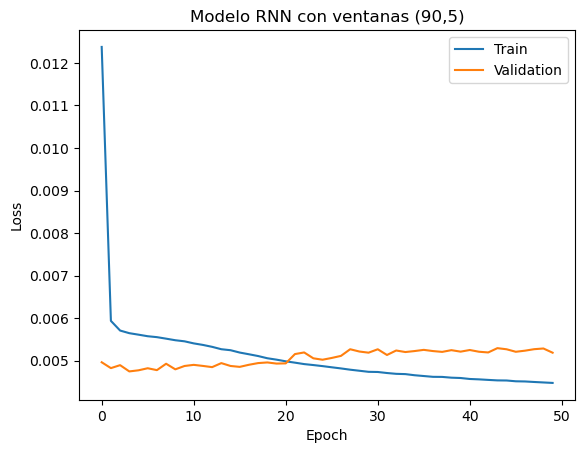

In [129]:
plt.plot(hist_RNN_90_5.history['loss'])
plt.plot(hist_RNN_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (90,5)')
plt.show()

##### 3.2.4.3. Modelo con 30 datos de salida

In [94]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_reg[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test[(90,30)]

In [95]:
model_RNN_90_30 = Sequential()

model_RNN_90_30.add(LSTM(64, input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_30.add(Dropout(0.3))
#model_RNN_90_30.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_30.add(LSTM(32))
model_RNN_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

model_RNN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_30.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_52 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_30 = model_RNN_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=50)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - loss: 0.0102 - val_loss: 0.0023
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - loss: 0.0026 - val_loss: 0.0020
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 125ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 12/50
339/339

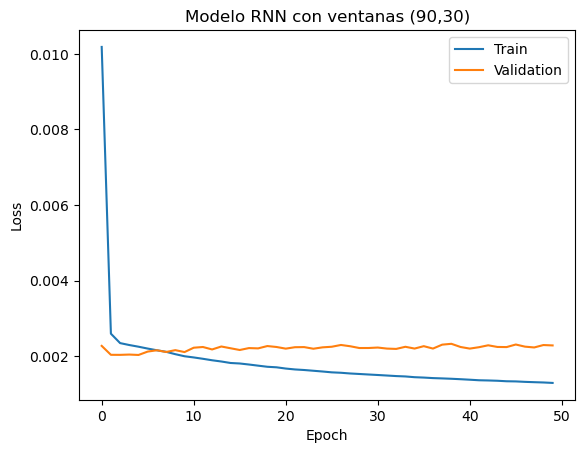

In [128]:
plt.plot(hist_RNN_90_30.history['loss'])
plt.plot(hist_RNN_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (90,30)')
plt.show()

##### 3.2.4.4. Modelo con 90 datos de salida

In [98]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_reg[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test[(90,90)]

In [99]:
model_RNN_90_90 = Sequential()

model_RNN_90_90.add(LSTM(64, input_shape=(train_data_90_90.shape[1], train_data_90_90.shape[2]), recurrent_dropout=0.2, return_sequences = True))
model_RNN_90_90.add(Dropout(0.3))
#model_RNN_90_90.add(LSTM(100, return_sequences = True))#,dropout=0.2,recurrent_dropout=0.2))
model_RNN_90_90.add(LSTM(32))
model_RNN_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

model_RNN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_RNN_90_90.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_54 (LSTM)                  │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_55 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_RNN_90_90 = model_RNN_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - loss: 0.0094 - val_loss: 0.0016
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 38s 112ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 9/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 11/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/50
338/338

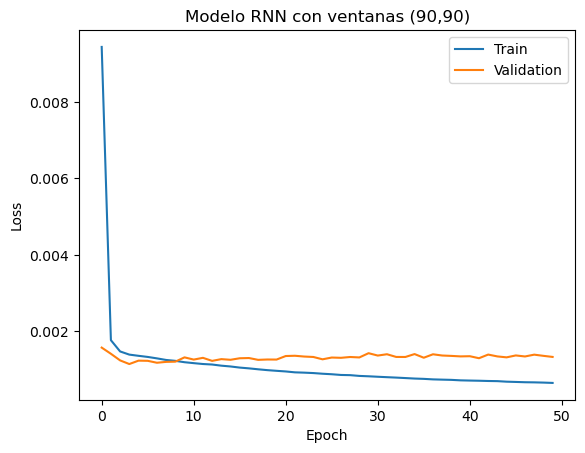

In [127]:
plt.plot(hist_RNN_90_90.history['loss'])
plt.plot(hist_RNN_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo RNN con ventanas (90,90)')
plt.show()

### 3.3 Modelos de capas convolucionales (CNN)

#### 3.3.1 Modelos con 5 datos de entrada

##### 3.3.1.1. Modelo con 1 dato de salida

In [ ]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_reg[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test[(5,1)]

In [112]:
model_CNN_5_1 = Sequential()

model_CNN_5_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2])))
model_CNN_5_1.add(MaxPooling1D())
#model_CNN_5_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_5_1.add(MaxPooling1D())
model_CNN_5_1.add(Convolution1D(filters=train_target_5_1.shape[1], kernel_size=1, activation="linear"))
model_CNN_5_1.add(GlobalAveragePooling1D())
#model_CNN_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_5_1.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 2, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_1 = model_CNN_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.1507 - val_loss: 0.0451
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0320 - val_loss: 0.0147
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0147 - val_loss: 0.0112
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0127 - val_loss: 0.0107
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0124 - val_loss: 0.0106
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0123 - val_loss: 0.0106
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0122 - val_loss: 0.0107
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4

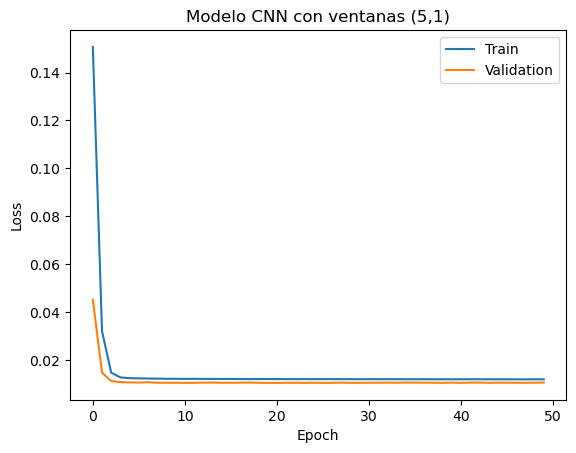

In [131]:
plt.plot(hist_CNN_5_1.history['loss'])
plt.plot(hist_CNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (5,1)')
plt.show()

##### 3.3.1.2. Modelo con 5 datos de salida

In [ ]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_reg[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test[(5,5)]

In [132]:
model_CNN_5_5 = Sequential()

model_CNN_5_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2])))
model_CNN_5_5.add(MaxPooling1D())
#model_CNN_5_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_5_5.add(MaxPooling1D())
model_CNN_5_5.add(Convolution1D(filters=train_target_5_5.shape[1], kernel_size=1, activation="linear"))
model_CNN_5_5.add(GlobalAveragePooling1D())
#model_CNN_5_5.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_5_5.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 2, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_5 = model_CNN_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.1438 - val_loss: 0.0449
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0294 - val_loss: 0.0108
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0095 - val_loss: 0.0061
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0069 - val_loss: 0.0055
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0065 - val_loss: 0.0053
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0063 - val_loss: 0.0051
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0061 - val_loss: 0.0051
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0059 - val_loss: 0.0049
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0059 - val_loss: 0.0049
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 

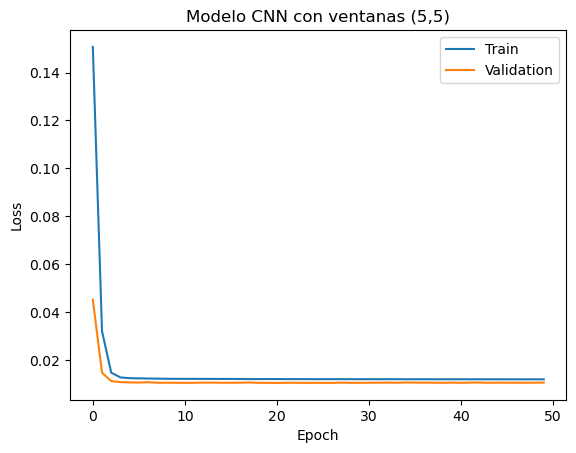

In [134]:
plt.plot(hist_CNN_5_1.history['loss'])
plt.plot(hist_CNN_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (5,5)')
plt.show()

##### 3.3.1.3. Modelo con 30 datos de salida

In [ ]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_reg[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test[(5,30)]

In [135]:
model_CNN_5_30 = Sequential()

model_CNN_5_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2])))
model_CNN_5_30.add(MaxPooling1D())
#model_CNN_5_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_5_30.add(MaxPooling1D())
model_CNN_5_30.add(Convolution1D(filters=train_target_5_30.shape[1], kernel_size=1, activation="linear"))
model_CNN_5_30.add(GlobalAveragePooling1D())
#model_CNN_5_30.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_5_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 2, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_30 = model_CNN_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1465 - val_loss: 0.0437
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0284 - val_loss: 0.0089
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0061 - val_loss: 0.0029
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 

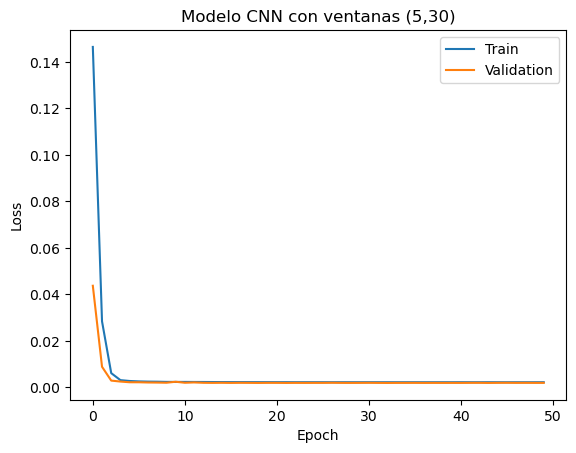

In [137]:
plt.plot(hist_CNN_5_30.history['loss'])
plt.plot(hist_CNN_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (5,30)')
plt.show()

##### 3.3.1.4. Modelo con 90 datos de salida

In [ ]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_reg[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test[(5,90)]

In [138]:
model_CNN_5_90 = Sequential()

model_CNN_5_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2])))
model_CNN_5_90.add(MaxPooling1D())
#model_CNN_5_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_5_90.add(MaxPooling1D())
model_CNN_5_90.add(Convolution1D(filters=train_target_5_90.shape[1], kernel_size=1, activation="linear"))
model_CNN_5_90.add(GlobalAveragePooling1D())
#model_CNN_5_90.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_5_90.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 5, 32)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 2, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_5_90 = model_CNN_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1547 - val_loss: 0.0477
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0301 - val_loss: 0.0084
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0050 - val_loss: 0.0019
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

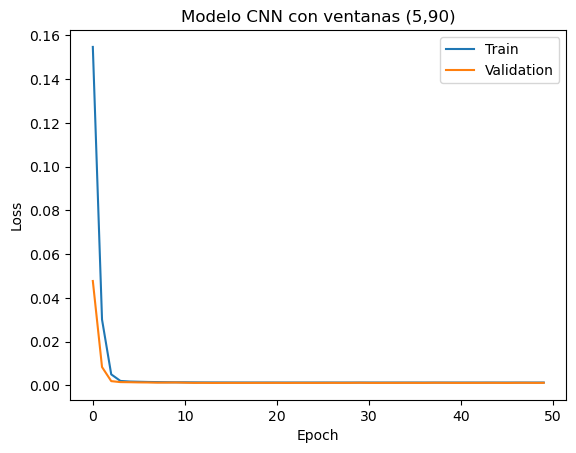

In [140]:
plt.plot(hist_CNN_5_90.history['loss'])
plt.plot(hist_CNN_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (5,90)')
plt.show()

#### 3.3.2 Modelos con 10 datos de entrada

##### 3.3.2.1. Modelo con 1 dato de salida

In [ ]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_reg[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test[(10,1)]

In [141]:
model_CNN_10_1 = Sequential()

model_CNN_10_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2])))
model_CNN_10_1.add(MaxPooling1D())
#model_CNN_10_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_10_1.add(MaxPooling1D())
model_CNN_10_1.add(Convolution1D(filters=train_target_10_1.shape[1], kernel_size=1, activation="linear"))
model_CNN_10_1.add(GlobalAveragePooling1D())
#model_CNN_10_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_10_1.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 5, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_1 = model_CNN_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.1113 - val_loss: 0.0415
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0311 - val_loss: 0.0174
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0157 - val_loss: 0.0116
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0128 - val_loss: 0.0107
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0123 - val_loss: 0.0107
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0122 - val_loss: 0.0105
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0121 - val_loss: 0.0106
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━━

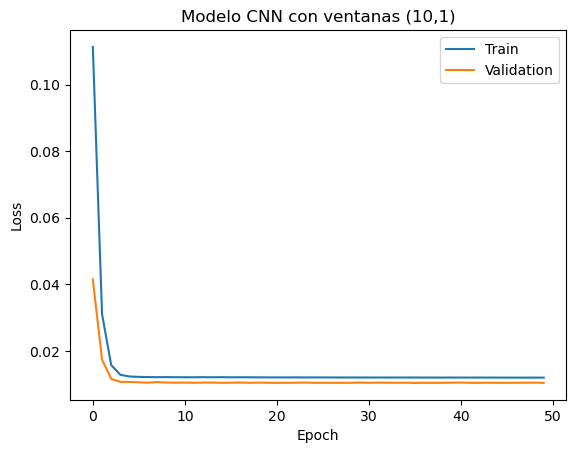

In [143]:
plt.plot(hist_CNN_10_1.history['loss'])
plt.plot(hist_CNN_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,1)')
plt.show()

##### 3.3.2.2. Modelo con 5 datos de salida

In [ ]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_reg[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test[(10,5)]

In [144]:
model_CNN_10_5 = Sequential()

model_CNN_10_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2])))
model_CNN_10_5.add(MaxPooling1D())
#model_CNN_10_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_10_5.add(MaxPooling1D())
model_CNN_10_5.add(Convolution1D(filters=train_target_10_5.shape[1], kernel_size=1, activation="linear"))
model_CNN_10_5.add(GlobalAveragePooling1D())
#model_CNN_10_5.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_10_5.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 5, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_5 = model_CNN_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.1121 - val_loss: 0.0411
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0285 - val_loss: 0.0132
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0099 - val_loss: 0.0059
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0064 - val_loss: 0.0051
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0060 - val_loss: 0.0049
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━━

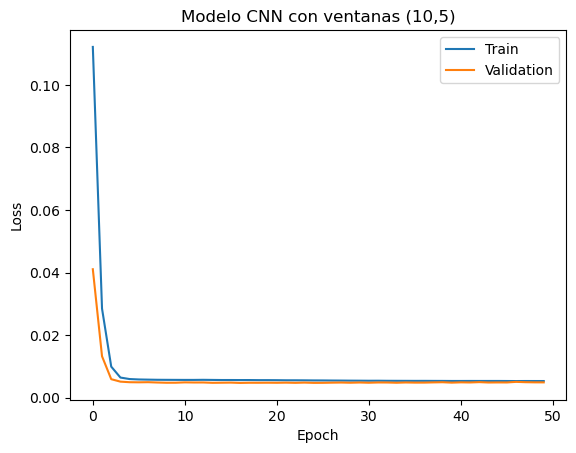

In [146]:
plt.plot(hist_CNN_10_5.history['loss'])
plt.plot(hist_CNN_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,5)')
plt.show()

##### 3.3.2.3. Modelo con 30 datos de salida

In [ ]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_reg[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test[(10,30)]

In [147]:
model_CNN_10_30 = Sequential()

model_CNN_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2])))
model_CNN_10_30.add(MaxPooling1D())
#model_CNN_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_10_30.add(MaxPooling1D())
model_CNN_10_30.add(Convolution1D(filters=train_target_10_30.shape[1], kernel_size=1, activation="linear"))
model_CNN_10_30.add(GlobalAveragePooling1D())
#model_CNN_10_30.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_10_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 5, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [148]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_30 = model_CNN_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.1138 - val_loss: 0.0428
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0277 - val_loss: 0.0113
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0069 - val_loss: 0.0028
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 

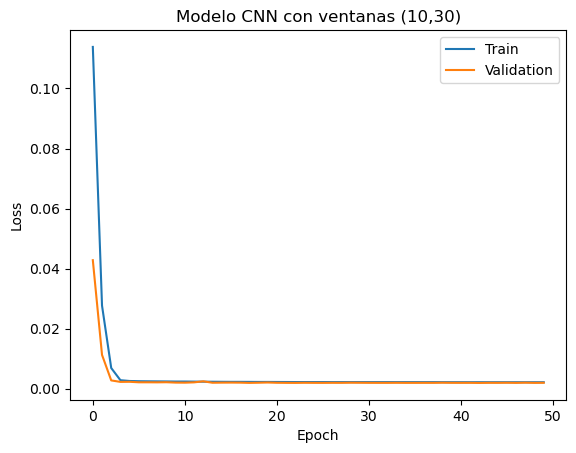

In [149]:
plt.plot(hist_CNN_10_30.history['loss'])
plt.plot(hist_CNN_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,30)')
plt.show()

##### 3.3.2.4. Modelo con 90 datos de salida

In [ ]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_reg[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test[(10,90)]

In [150]:
model_CNN_10_90 = Sequential()

model_CNN_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2])))
model_CNN_10_90.add(MaxPooling1D())
#model_CNN_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_10_90.add(MaxPooling1D())
model_CNN_10_90.add(Convolution1D(filters=train_target_10_90.shape[1], kernel_size=1, activation="linear"))
model_CNN_10_90.add(GlobalAveragePooling1D())
#model_CNN_10_90.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_10_90.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 10, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 5, 23)          │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_10_90 = model_CNN_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0995 - val_loss: 0.0374
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0262 - val_loss: 0.0108
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0021 - val_loss: 0.0016
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 5

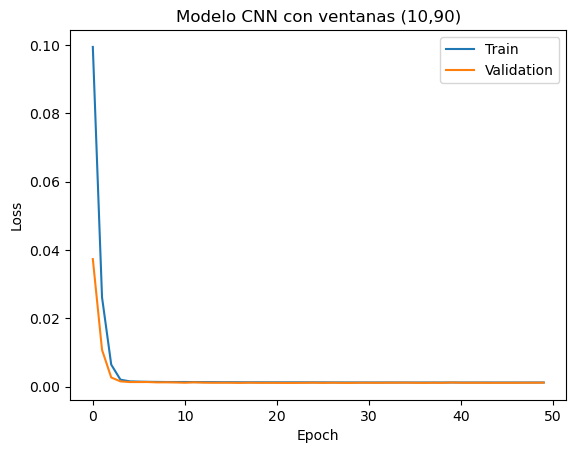

In [152]:
plt.plot(hist_CNN_10_90.history['loss'])
plt.plot(hist_CNN_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (10,90)')
plt.show()

#### 3.3.3 Modelos con 30 datos de entrada

##### 3.3.3.1. Modelo con 1 dato de salida

In [ ]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_reg[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test[(30,1)]

In [153]:
model_CNN_30_1 = Sequential()

model_CNN_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2])))
model_CNN_30_1.add(MaxPooling1D())
#model_CNN_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_30_1.add(MaxPooling1D())
model_CNN_30_1.add(Convolution1D(filters=train_target_30_1.shape[1], kernel_size=1, activation="linear"))
model_CNN_30_1.add(GlobalAveragePooling1D())
#model_CNN_30_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_30_1.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 15, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_1 = model_CNN_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0730 - val_loss: 0.0376
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0262 - val_loss: 0.0207
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0167 - val_loss: 0.0140
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0136 - val_loss: 0.0115
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0126 - val_loss: 0.0109
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0123 - val_loss: 0.0106
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - val_loss: 0.0105
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - val_loss: 0.0104
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/

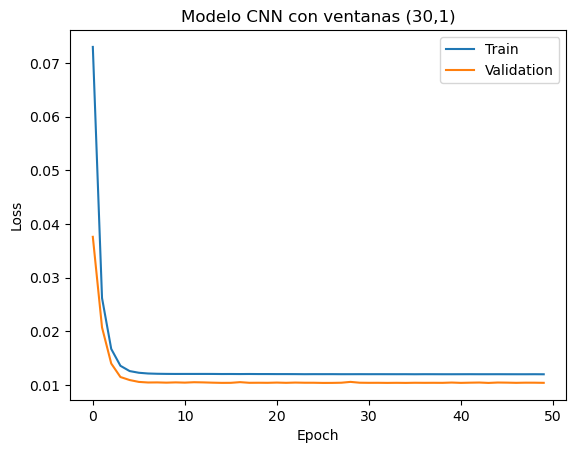

In [155]:
plt.plot(hist_CNN_30_1.history['loss'])
plt.plot(hist_CNN_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,1)')
plt.show()

##### 3.3.3.2. Modelo con 5 datos de salida

In [ ]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_reg[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test[(30,5)]

In [156]:
model_CNN_30_5 = Sequential()

model_CNN_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2])))
model_CNN_30_5.add(MaxPooling1D())
#model_CNN_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_30_5.add(MaxPooling1D())
model_CNN_30_5.add(Convolution1D(filters=train_target_30_5.shape[1], kernel_size=1, activation="linear"))
model_CNN_30_5.add(GlobalAveragePooling1D())
#model_CNN_30_5.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_30_5.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_23 (Conv1D)              │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 15, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [157]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_5 = model_CNN_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0735 - val_loss: 0.0333
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0228 - val_loss: 0.0163
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0113 - val_loss: 0.0083
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0070 - val_loss: 0.0054
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0059 - val_loss: 0.0049
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0056 - val_loss: 0.0048
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━

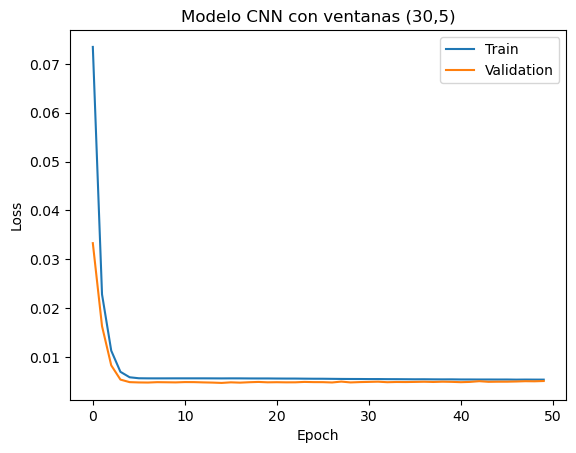

In [158]:
plt.plot(hist_CNN_30_5.history['loss'])
plt.plot(hist_CNN_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,5)')
plt.show()

##### 3.3.3.3. Modelo con 30 datos de salida

In [ ]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_reg[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test[(30,30)]

In [159]:
model_CNN_30_30 = Sequential()

model_CNN_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2])))
model_CNN_30_30.add(MaxPooling1D())
#model_CNN_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_30_30.add(MaxPooling1D())
model_CNN_30_30.add(Convolution1D(filters=train_target_30_30.shape[1], kernel_size=1, activation="linear"))
model_CNN_30_30.add(GlobalAveragePooling1D())
#model_CNN_30_30.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_30_30.summary()

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 15, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_30 = model_CNN_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=50)

Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0712 - val_loss: 0.0335
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0208 - val_loss: 0.0147
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0085 - val_loss: 0.0055
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0034 - val_loss: 0.0025
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 12/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

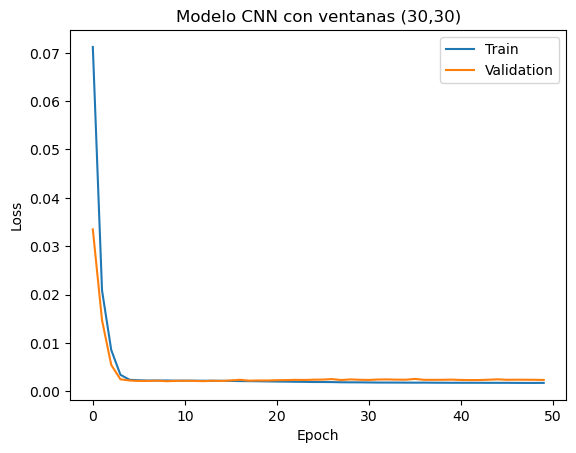

In [161]:
plt.plot(hist_CNN_30_30.history['loss'])
plt.plot(hist_CNN_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,30)')
plt.show()

##### 3.3.3.4. Modelo con 90 datos de salida

In [ ]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_reg[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test[(30,90)]

In [162]:
model_CNN_30_90 = Sequential()

model_CNN_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2])))
model_CNN_30_90.add(MaxPooling1D())
#model_CNN_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_30_90.add(MaxPooling1D())
model_CNN_30_90.add(Convolution1D(filters=train_target_30_90.shape[1], kernel_size=1, activation="linear"))
model_CNN_30_90.add(GlobalAveragePooling1D())
#model_CNN_30_90.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_30_90.summary()

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 30, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 15, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [163]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_30_90 = model_CNN_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=50)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0722 - val_loss: 0.0331
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0204 - val_loss: 0.0145
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0083 - val_loss: 0.0050
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0027 - val_loss: 0.0016
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 12/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

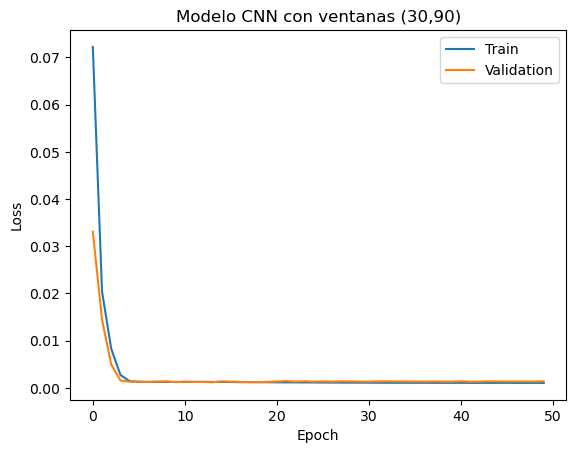

In [164]:
plt.plot(hist_CNN_30_90.history['loss'])
plt.plot(hist_CNN_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (30,90)')
plt.show()

#### 3.3.4 Modelos con 90 datos de entrada

##### 3.3.4.1. Modelo con 1 dato de salida

In [ ]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_reg[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test[(90,1)]

In [165]:
model_CNN_90_1 = Sequential()

model_CNN_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2])))
model_CNN_90_1.add(MaxPooling1D())
#model_CNN_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_90_1.add(MaxPooling1D())
model_CNN_90_1.add(Convolution1D(filters=train_target_90_1.shape[1], kernel_size=1, activation="linear"))
model_CNN_90_1.add(GlobalAveragePooling1D())
#model_CNN_90_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_90_1.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_29 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [166]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_1 = model_CNN_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0724 - val_loss: 0.0343
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0204 - val_loss: 0.0237
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0162 - val_loss: 0.0193
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0145 - val_loss: 0.0161
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0136 - val_loss: 0.0148
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0131 - val_loss: 0.0135
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0128 - val_loss: 0.0127
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0126 - val_loss: 0.0120
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0124 - val_loss: 0.0114
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0124 - val_loss: 0.0110
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0123 - val_loss: 0.0109
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/ste

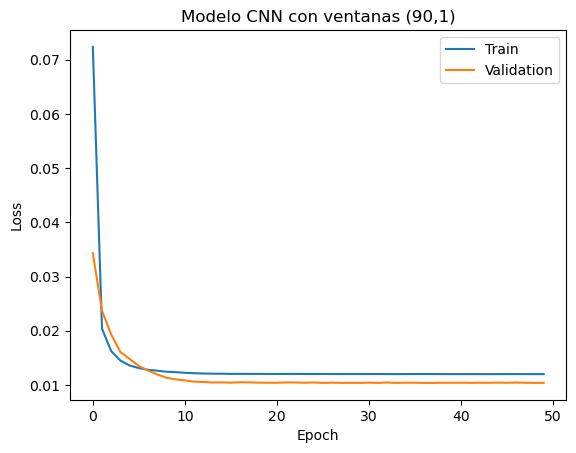

In [167]:
plt.plot(hist_CNN_90_1.history['loss'])
plt.plot(hist_CNN_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,1)')
plt.show()

##### 3.3.4.2. Modelo con 5 datos de salida

In [ ]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_reg[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test[(90,5)]

In [168]:
model_CNN_90_5 = Sequential()

model_CNN_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2])))
model_CNN_90_5.add(MaxPooling1D())
#model_CNN_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_90_5.add(MaxPooling1D())
model_CNN_90_5.add(Convolution1D(filters=train_target_90_5.shape[1], kernel_size=1, activation="linear"))
model_CNN_90_5.add(GlobalAveragePooling1D())
#model_CNN_90_5.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_90_5.summary()

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_15     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [169]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_5 = model_CNN_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=50)

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0508 - val_loss: 0.0300
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0167 - val_loss: 0.0207
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0114 - val_loss: 0.0151
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0088 - val_loss: 0.0109
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0075 - val_loss: 0.0086
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - val_loss: 0.0072
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0062 - val_loss: 0.0064
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 9/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0058 - val_loss: 0.0054
Epoch 10/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 11/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 12/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/

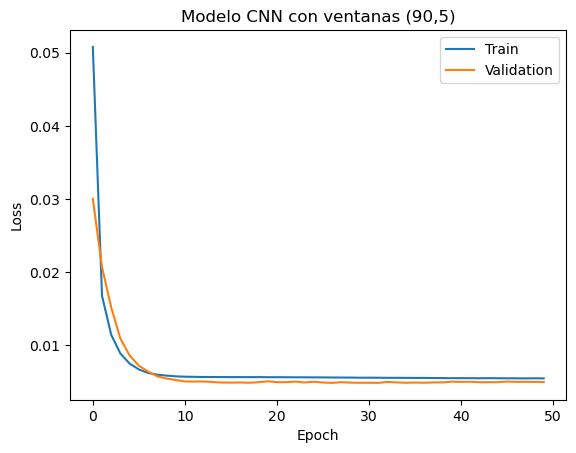

In [170]:
plt.plot(hist_CNN_90_5.history['loss'])
plt.plot(hist_CNN_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,5)')
plt.show()

##### 3.3.4.3. Modelo con 30 datos de salida

In [ ]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_reg[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test[(90,30)]

In [171]:
model_CNN_90_30 = Sequential()

model_CNN_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2])))
model_CNN_90_30.add(MaxPooling1D())
#model_CNN_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_90_30.add(MaxPooling1D())
model_CNN_90_30.add(Convolution1D(filters=train_target_90_30.shape[1], kernel_size=1, activation="linear"))
model_CNN_90_30.add(GlobalAveragePooling1D())
#model_CNN_90_30.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_90_30.summary()

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_16     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_30 = model_CNN_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=50)

Epoch 1/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0605 - val_loss: 0.0303
Epoch 2/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0151 - val_loss: 0.0192
Epoch 3/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0090 - val_loss: 0.0122
Epoch 4/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0059 - val_loss: 0.0084
Epoch 5/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0041 - val_loss: 0.0054
Epoch 6/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0031 - val_loss: 0.0039
Epoch 7/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 8/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 9/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 10/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 11/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 12/50
339/339 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

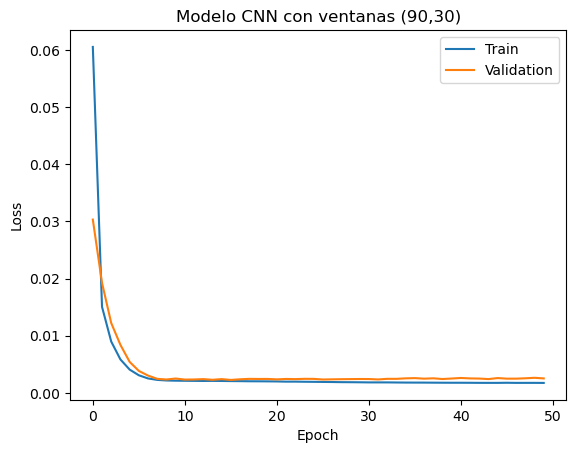

In [173]:
plt.plot(hist_CNN_90_30.history['loss'])
plt.plot(hist_CNN_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,30)')
plt.show()

##### 3.3.4.4. Modelo con 90 datos de salida

In [ ]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_reg[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test[(90,90)]

In [174]:
model_CNN_90_90 = Sequential()

model_CNN_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_90.shape[1], train_data_90_90.shape[2])))
model_CNN_90_90.add(MaxPooling1D())
#model_CNN_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu"))
#model_CNN_90_90.add(MaxPooling1D())
model_CNN_90_90.add(Convolution1D(filters=train_target_90_90.shape[1], kernel_size=1, activation="linear"))
model_CNN_90_90.add(GlobalAveragePooling1D())
#model_CNN_90_90.add(Dense(train_target_5_1.shape[1], activation='linear'))

model_CNN_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

model_CNN_90_90.summary()

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 90, 32)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 45, 23)         │           759 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_17     │ (None, 23)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999 (11.71 KB)

 Trainable params: 2,999 (11.71 KB)

 Non-trainable params: 0 (0.00 B)

In [175]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_CNN_90_90 = model_CNN_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=50)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0495 - val_loss: 0.0292
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0145 - val_loss: 0.0186
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0087 - val_loss: 0.0121
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0055 - val_loss: 0.0079
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0035 - val_loss: 0.0049
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 9/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 10/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 11/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 12/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/s

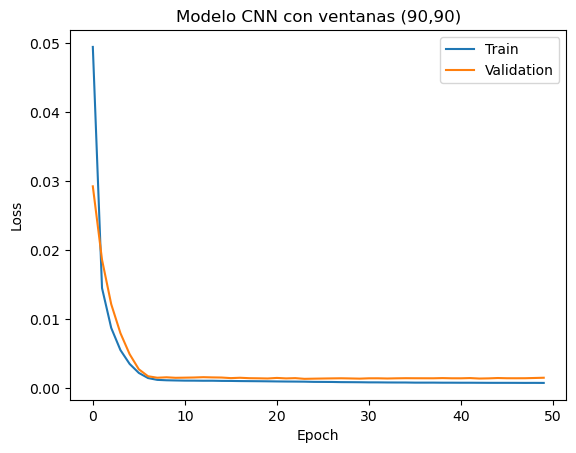

In [176]:
plt.plot(hist_CNN_90_90.history['loss'])
plt.plot(hist_CNN_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo CNN con ventanas (90,90)')
plt.show()

### 3.4 Modelos de capas mixtas

#### 3.4.1 Modelos con 5 datos de entrada

##### 3.4.1.1. Modelo con 1 dato de salida

In [39]:
train_data_5_1, train_target_5_1 = dicc_data_train_norm[(5,1)], dicc_target_train_norm[(5,1)]
val_data_5_1, val_target_5_1 = dicc_data_val_norm[(5,1)], dicc_target_val_norm[(5,1)]
test_data_5_1, test_target_5_1 = dicc_data_test_norm[(5,1)], dicc_target_test_norm[(5,1)]

In [43]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_1 = Sequential()

# Capas CNN
model_mixto_5_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_1.shape[1], train_data_5_1.shape[2])))
#model_mixto_5_1.add(MaxPooling1D())
#model_mixto_5_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_5_1.add(MaxPooling1D())

# Capas RNN
#model_mixto_5_1.add(LSTM(64, return_sequences=True))
model_mixto_5_1.add(LSTM(64))
#model_mixto_5_1.add(Dropout(0.5))

# Capas NN
#model_mixto_5_1.add(Dense(64, activation='relu'))
#model_mixto_5_1.add(Dropout(0.5))
model_mixto_5_1.add(Dense(train_target_5_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.01))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_1 = model_mixto_5_1.fit(train_data_5_1, train_target_5_1, validation_data=(val_data_5_1, val_target_5_1), epochs=50)

Epoch 1/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.7004 - val_loss: 0.6137
Epoch 2/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.6991 - val_loss: 0.6143
Epoch 3/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6989 - val_loss: 0.6137
Epoch 4/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6983 - val_loss: 0.6147
Epoch 5/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6978 - val_loss: 0.6147
Epoch 6/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6964 - val_loss: 0.6174
Epoch 7/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6959 - val_loss: 0.6178
Epoch 8/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6949 - val_loss: 0.6189
Epoch 9/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6935 - val_loss: 0.6216
Epoch 10/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6926 - val_loss: 0.6189
Epoch 11/50
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6925 - val_loss: 0.6201
Epoch 12/50
342/342 ━━━━━━━━━━━━━━━━━━━━

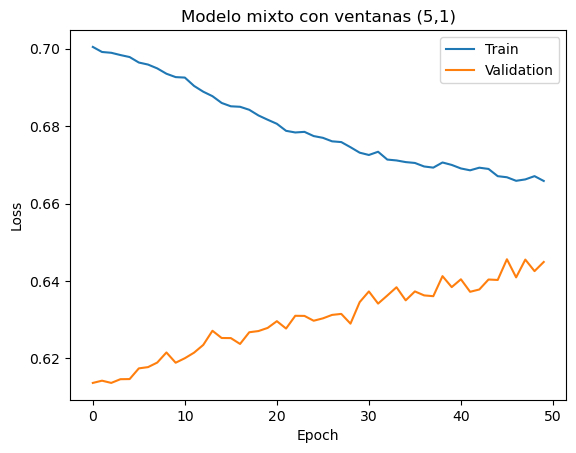

In [45]:
plt.plot(hist_mixto_5_1.history['loss'])
plt.plot(hist_mixto_5_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_1 = model_mixto_5_1.predict(train_data_5_1)
y_pred_nn_scaled_val_5_1 = model_mixto_5_1.predict(val_data_5_1)
y_pred_nn_scaled_test_5_1 = model_mixto_5_1.predict(test_data_5_1)

# 2. Deshacemos la normalización usando el scaler de la llave (5,1)
scaler_y_5_1 = dicc_scaler[(5,1)]
y_pred_nn_real_train_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_train_5_1)
y_pred_nn_real_val_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_val_5_1)
y_pred_nn_real_test_5_1 = scaler_y_5_1.inverse_transform(y_pred_nn_scaled_test_5_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_1 = mean_absolute_error(dicc_target_train_reg[(5,1)], y_pred_nn_real_train_5_1)
mae_nn_val_5_1 = mean_absolute_error(dicc_target_val[(5,1)], y_pred_nn_real_val_5_1)
mae_nn_test_5_1 = mean_absolute_error(dicc_target_test[(5,1)], y_pred_nn_real_test_5_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_1:.6f}")
print()

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=======   Resultados modelo mixto (5,1)   =======

MAE de la Regresión Lineal (train): 0.011929
MAE de la Red Neuronal (train):     0.011319

MAE de la Regresión Lineal (val): 0.010497
MAE de la Red Neuronal (val):     0.010904

MAE de la Regresión Lineal (test): 0.012439
MAE de la Red Neuronal (test):     0.012791



##### 3.4.1.2. Modelo con 5 datos de salida

In [ ]:
train_data_5_5, train_target_5_5 = dicc_data_train_norm[(5,5)], dicc_target_train_norm[(5,5)]
val_data_5_5, val_target_5_5 = dicc_data_val_norm[(5,5)], dicc_target_val_norm[(5,5)]
test_data_5_5, test_target_5_5 = dicc_data_test_norm[(5,5)], dicc_target_test_norm[(5,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_5 = Sequential()

# Capas CNN
model_mixto_5_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_5.shape[1], train_data_5_5.shape[2])))
model_mixto_5_5.add(MaxPooling1D())
#model_mixto_5_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_5_5.add(MaxPooling1D())

# Capas RNN
#model_mixto_5_5.add(LSTM(64, return_sequences=True))
model_mixto_5_5.add(LSTM(32))
#model_mixto_5_1.add(Dropout(0.5))

# Capas NN
model_mixto_5_5.add(Dense(64, activation='relu'))
model_mixto_5_1.add(Dropout(0.5))
model_mixto_5_5.add(Dense(train_target_5_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0005))

In [38]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_5 = model_mixto_5_5.fit(train_data_5_5, train_target_5_5, validation_data=(val_data_5_5, val_target_5_5), epochs=200)

Epoch 1/200


342/342 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0108 - val_loss: 0.0047
Epoch 2/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 3/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 4/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 5/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 6/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 7/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0046
Epoch 8/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 9/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 10/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 11/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 12/200
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/

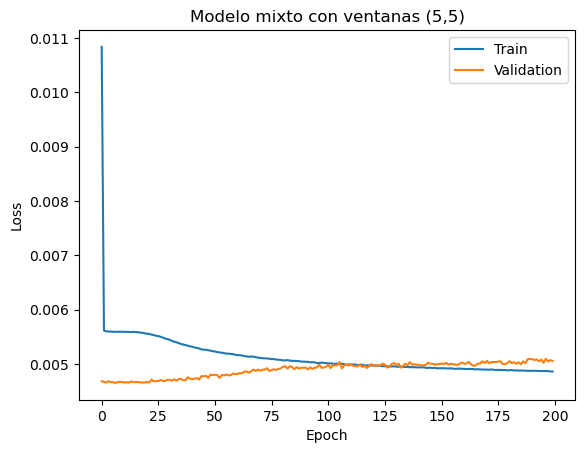

In [39]:
plt.plot(hist_mixto_5_5.history['loss'])
plt.plot(hist_mixto_5_5.history['val_loss'])
#plt.plot(aux_mixto_5_5.history['loss'] + hist_mixto_5_5.history['loss'])
#plt.plot(aux_mixto_5_5.history['val_loss'] + hist_mixto_5_5.history['val_loss'])
#plt.plot(aux_mixto_5_5.history['loss'] + aux_mixto_5_5_2.history['loss'] + hist_mixto_5_5.history['loss'])
#plt.plot(aux_mixto_5_5.history['val_loss'] + aux_mixto_5_5_2.history['val_loss'] + hist_mixto_5_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_5 = model_mixto_5_5.predict(train_data_5_5)
y_pred_nn_scaled_val_5_5 = model_mixto_5_5.predict(val_data_5_5)
y_pred_nn_scaled_test_5_5 = model_mixto_5_5.predict(test_data_5_5)

# 2. Deshacemos la normalización usando el scaler de la llave (5,5)
scaler_y_5_5 = dicc_scaler[(5,5)]
y_pred_nn_real_train_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_train_5_5)
y_pred_nn_real_val_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_val_5_5)
y_pred_nn_real_test_5_5 = scaler_y_5_5.inverse_transform(y_pred_nn_scaled_test_5_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_5 = mean_absolute_error(dicc_target_train_reg[(5,5)], y_pred_nn_real_train_5_5)
mae_nn_val_5_5 = mean_absolute_error(dicc_target_val[(5,5)], y_pred_nn_real_val_5_5)
mae_nn_test_5_5 = mean_absolute_error(dicc_target_test[(5,5)], y_pred_nn_real_test_5_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_5:.6f}")
print()

##### 3.4.1.3. Modelo con 30 datos de salida

In [ ]:
train_data_5_30, train_target_5_30 = dicc_data_train_norm[(5,30)], dicc_target_train_norm[(5,30)]
val_data_5_30, val_target_5_30 = dicc_data_val_norm[(5,30)], dicc_target_val_norm[(5,30)]
test_data_5_30, test_target_5_30 = dicc_data_test_norm[(5,30)], dicc_target_test_norm[(5,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_30 = Sequential()

# Capas CNN
model_mixto_5_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_30.shape[1], train_data_5_30.shape[2])))
model_mixto_5_30.add(MaxPooling1D())
#model_mixto_5_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='valid'))
#model_mixto_5_30.add(MaxPooling1D())

# Capas RNN
#model_mixto_5_30.add(LSTM(64, return_sequences=True))
model_mixto_5_30.add(LSTM(32))
#model_mixto_5_30.add(Dropout(0.5))

# Capas NN
model_mixto_5_30.add(Dense(80, activation='relu'))
model_mixto_5_30.add(Dropout(0.2))
model_mixto_5_30.add(Dense(train_target_5_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [53]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_30 = model_mixto_5_30.fit(train_data_5_30, train_target_5_30, validation_data=(val_data_5_30, val_target_5_30), epochs=150)

Epoch 1/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0052 - val_loss: 0.0019
Epoch 2/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 3/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 4/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 5/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 6/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 7/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 8/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 9/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 10/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 11/150
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 12/150
341/341 ━━━━━━━━━━━━━━━━

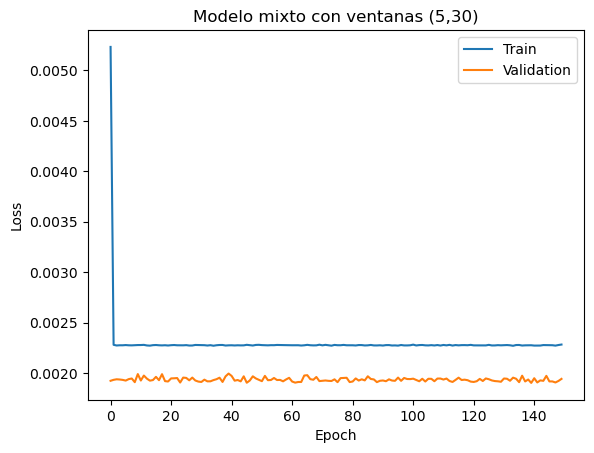

In [55]:
plt.plot(hist_mixto_5_30.history['loss'])
plt.plot(hist_mixto_5_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_30 = model_mixto_5_30.predict(train_data_5_30)
y_pred_nn_scaled_val_5_30 = model_mixto_5_30.predict(val_data_5_30)
y_pred_nn_scaled_test_5_30 = model_mixto_5_30.predict(test_data_5_30)

# 2. Deshacemos la normalización usando el scaler de la llave (5,30)
scaler_y_5_30 = dicc_scaler[(5,30)]
y_pred_nn_real_train_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_train_5_30)
y_pred_nn_real_val_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_val_5_30)
y_pred_nn_real_test_5_30 = scaler_y_5_30.inverse_transform(y_pred_nn_scaled_test_5_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_30 = mean_absolute_error(dicc_target_train_reg[(5,30)], y_pred_nn_real_train_5_30)
mae_nn_val_5_30 = mean_absolute_error(dicc_target_val[(5,30)], y_pred_nn_real_val_5_30)
mae_nn_test_5_30 = mean_absolute_error(dicc_target_test[(5,30)], y_pred_nn_real_test_5_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_30:.6f}")
print()

##### 3.4.1.4. Modelo con 90 datos de salida

In [ ]:
train_data_5_90, train_target_5_90 = dicc_data_train_norm[(5,90)], dicc_target_train_norm[(5,90)]
val_data_5_90, val_target_5_90 = dicc_data_val_norm[(5,90)], dicc_target_val_norm[(5,90)]
test_data_5_90, test_target_5_90 = dicc_data_test_norm[(5,90)], dicc_target_test_norm[(5,90)]

In [57]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_5_90 = Sequential()

# Capas CNN
model_mixto_5_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_5_90.shape[1], train_data_5_90.shape[2])))
model_mixto_5_90.add(MaxPooling1D())
#model_mixto_5_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_5_90.add(MaxPooling1D())

# Capas RNN
model_mixto_5_90.add(LSTM(64, return_sequences=True))
model_mixto_5_90.add(LSTM(32))

# Capas NN
model_mixto_5_90.add(Dense(64, activation='relu'))
model_mixto_5_90.add(Dropout(0.3))
model_mixto_5_90.add(Dense(train_target_5_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_5_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_5_90 = model_mixto_5_90.fit(train_data_5_90, train_target_5_90, validation_data=(val_data_5_90, val_target_5_90), epochs=200)

Epoch 1/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 2/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 4/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 6/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 7/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 8/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/200
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 12/200
340/340 ━━━━━━━━

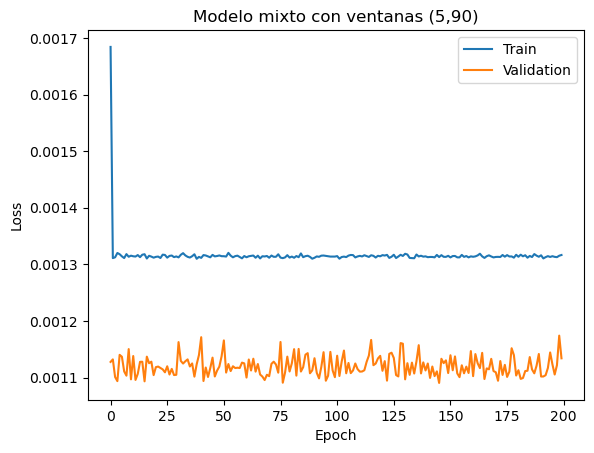

In [60]:
plt.plot(hist_mixto_5_90.history['loss'])
plt.plot(hist_mixto_5_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (5,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_5_90 = model_mixto_5_90.predict(train_data_5_90)
y_pred_nn_scaled_val_5_90 = model_mixto_5_90.predict(val_data_5_90)
y_pred_nn_scaled_test_5_90 = model_mixto_5_90.predict(test_data_5_90)

# 2. Deshacemos la normalización usando el scaler de la llave (5,90)
scaler_y_5_90 = dicc_scaler[(5,90)]
y_pred_nn_real_train_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_train_5_90)
y_pred_nn_real_val_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_val_5_90)
y_pred_nn_real_test_5_90 = scaler_y_5_90.inverse_transform(y_pred_nn_scaled_test_5_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_5_90 = mean_absolute_error(dicc_target_train_reg[(5,90)], y_pred_nn_real_train_5_90)
mae_nn_val_5_90 = mean_absolute_error(dicc_target_val[(5,90)], y_pred_nn_real_val_5_90)
mae_nn_test_5_90 = mean_absolute_error(dicc_target_test[(5,90)], y_pred_nn_real_test_5_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (5,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_5_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(5,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_5_90:.6f}")
print()

#### 3.4.2 Modelos con 10 datos de entrada

##### 3.4.2.1. Modelo con 1 dato de salida

In [ ]:
train_data_10_1, train_target_10_1 = dicc_data_train_norm[(10,1)], dicc_target_train_norm[(10,1)]
val_data_10_1, val_target_10_1 = dicc_data_val_norm[(10,1)], dicc_target_val_norm[(10,1)]
test_data_10_1, test_target_10_1 = dicc_data_test_norm[(10,1)], dicc_target_test_norm[(10,1)]

In [65]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_1 = Sequential()

# Capas CNN
model_mixto_10_1.add(Convolution1D(filters=32, kernel_size=2, activation="relu", padding='same', input_shape=(train_data_10_1.shape[1], train_data_10_1.shape[2])))
model_mixto_10_1.add(MaxPooling1D())
#model_mixto_10_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_10_1.add(MaxPooling1D())

# Capas RNN
#model_mixto_10_1.add(LSTM(64, return_sequences=True))
model_mixto_10_1.add(LSTM(64))

# Capas NN
model_mixto_10_1.add(Dense(50, activation='relu'))
#model_mixto_10_1.add(Dropout(0.2))
model_mixto_10_1.add(Dense(train_target_10_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [66]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_1 = model_mixto_10_1.fit(train_data_10_1, train_target_10_1, validation_data=(val_data_10_1, val_target_10_1), epochs=150)

Epoch 1/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0135 - val_loss: 0.0104
Epoch 2/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0120 - val_loss: 0.0105
Epoch 3/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 4/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 5/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 6/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 7/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 8/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 9/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 10/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 11/150
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0120 - val_loss: 0.0104
Epoch 12/150
342/342 ━━━━━━━━━━━━━━

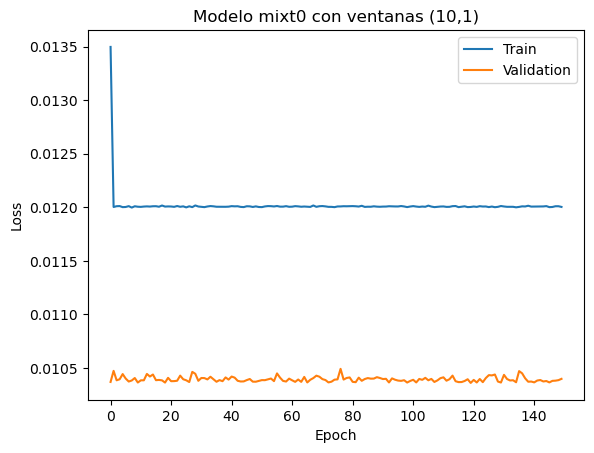

In [67]:
plt.plot(hist_mixto_10_1.history['loss'])
plt.plot(hist_mixto_10_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixt0 con ventanas (10,1)')
plt.show()

##### 3.4.2.2. Modelo con 5 datos de salida

In [ ]:
train_data_10_5, train_target_10_5 = dicc_data_train_norm[(10,5)], dicc_target_train_norm[(10,5)]
val_data_10_5, val_target_10_5 = dicc_data_val_norm[(10,5)], dicc_target_val_norm[(10,5)]
test_data_10_5, test_target_10_5 = dicc_data_test_norm[(10,5)], dicc_target_test_norm[(10,5)]

In [86]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_5 = Sequential()

# Capas CNN
model_mixto_10_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_5.shape[1], train_data_10_5.shape[2])))
model_mixto_10_5.add(MaxPooling1D(pool_size = 1))
model_mixto_10_5.add(Convolution1D(filters=64, kernel_size=3, activation="relu", padding='same'))
#model_mixto_10_5.add(MaxPooling1D())

# Capas RNN
model_mixto_10_5.add(LSTM(64, return_sequences=True))
model_mixto_10_5.add(Dropout(0.2))
model_mixto_10_5.add(LSTM(32))

# Capas NN
model_mixto_10_5.add(Dense(64, activation='relu'))
#model_mixto_10_5.add(Dropout(0.2))
model_mixto_10_5.add(Dense(train_target_10_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.005))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_5 = model_mixto_10_5.fit(train_data_10_5, train_target_10_5, validation_data=(val_data_10_5, val_target_10_5), epochs=30)

Epoch 1/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0063 - val_loss: 0.0048
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0057 - val_loss: 0.0049
Epoch 7/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 8/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0058 - val_loss: 0.0048
Epoch 9/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 10/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 11/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0057 - val_loss: 0.0048
Epoch 12/30
342/342 ━━━━━━━━━━━━━━━━━━

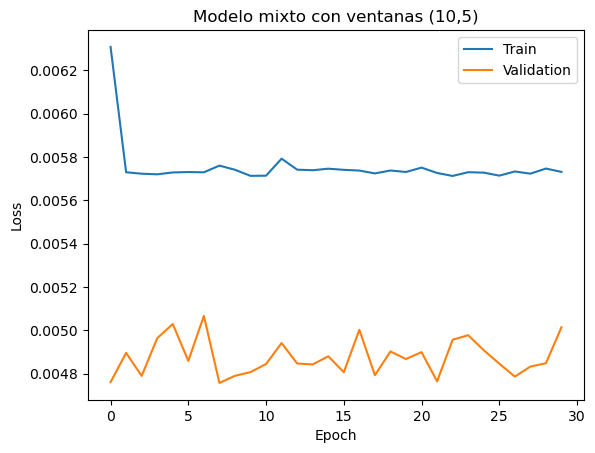

In [88]:
plt.plot(hist_mixto_10_5.history['loss'])
plt.plot(hist_mixto_10_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,5)')
plt.show()

##### 3.4.2.3. Modelo con 30 datos de salida

In [ ]:
train_data_10_30, train_target_10_30 = dicc_data_train_norm[(10,30)], dicc_target_train_norm[(10,30)]
val_data_10_30, val_target_10_30 = dicc_data_val_norm[(10,30)], dicc_target_val_norm[(10,30)]
test_data_10_30, test_target_10_30 = dicc_data_test_norm[(10,30)], dicc_target_test_norm[(10,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_30 = Sequential()

# Capas CNN
model_mixto_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_30.shape[1], train_data_10_30.shape[2])))
model_mixto_10_30.add(MaxPooling1D())
#model_mixto_10_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_10_30.add(MaxPooling1D())

# Capas RNN
model_mixto_10_30.add(LSTM(32, return_sequences=True))
model_mixto_10_30.add(LSTM(16))

# Capas NN
model_mixto_10_30.add(Dense(50, activation='relu'))
model_mixto_10_30.add(Dense(train_target_10_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_30 = model_mixto_10_30.fit(train_data_10_30, train_target_10_30, validation_data=(val_data_10_30, val_target_10_30), epochs=50)

In [ ]:
plt.plot(hist_mixto_10_30.history['loss'])
plt.plot(hist_mixto_10_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,30)')
plt.show()

##### 3.4.2.4. Modelo con 90 datos de salida

In [ ]:
train_data_10_90, train_target_10_90 = dicc_data_train_norm[(10,90)], dicc_target_train_norm[(10,90)]
val_data_10_90, val_target_10_90 = dicc_data_val_norm[(10,90)], dicc_target_val_norm[(10,90)]
test_data_10_90, test_target_10_90 = dicc_data_test_norm[(10,90)], dicc_target_test_norm[(10,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_10_90 = Sequential()

# Capas CNN
model_mixto_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_10_90.shape[1], train_data_10_90.shape[2])))
model_mixto_10_90.add(MaxPooling1D())
#model_mixto_10_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_10_90.add(MaxPooling1D())

# Capas RNN
model_mixto_10_90.add(LSTM(32, return_sequences=True))
model_mixto_10_90.add(LSTM(16))

# Capas NN
model_mixto_10_90.add(Dense(50, activation='relu'))
model_mixto_10_90.add(Dense(train_target_10_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_10_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_10_90 = model_mixto_10_90.fit(train_data_10_90, train_target_10_90, validation_data=(val_data_10_90, val_target_10_90), epochs=50)

In [ ]:
plt.plot(hist_mixto_10_90.history['loss'])
plt.plot(hist_mixto_10_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (10,90)')
plt.show()

#### 3.4.3 Modelos con 30 datos de entrada

##### 3.4.3.1. Modelo con 1 dato de salida

In [ ]:
train_data_30_1, train_target_30_1 = dicc_data_train_norm[(30,1)], dicc_target_train_norm[(30,1)]
val_data_30_1, val_target_30_1 = dicc_data_val_norm[(30,1)], dicc_target_val_norm[(30,1)]
test_data_30_1, test_target_30_1 = dicc_data_test_norm[(30,1)], dicc_target_test_norm[(30,1)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_1 = Sequential()

# Capas CNN
model_mixto_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_1.shape[1], train_data_30_1.shape[2])))
model_mixto_30_1.add(MaxPooling1D())
#model_mixto_30_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_30_1.add(MaxPooling1D())

# Capas RNN
model_mixto_30_1.add(LSTM(32, return_sequences=True))
model_mixto_30_1.add(LSTM(16))

# Capas NN
model_mixto_30_1.add(Dense(50, activation='relu'))
model_mixto_30_1.add(Dense(train_target_30_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_1 = model_mixto_30_1.fit(train_data_30_1, train_target_30_1, validation_data=(val_data_30_1, val_target_30_1), epochs=50)

In [ ]:
plt.plot(hist_mixto_30_1.history['loss'])
plt.plot(hist_mixto_30_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_1 = model_mixto_30_1.predict(train_data_30_1)
y_pred_nn_scaled_val_30_1 = model_mixto_30_1.predict(val_data_30_1)
y_pred_nn_scaled_test_30_1 = model_mixto_30_1.predict(test_data_30_1)

# 2. Deshacemos la normalización usando el scaler de la llave (30,1)
scaler_y_30_1 = dicc_scaler[(30,1)]
y_pred_nn_real_train_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_train_30_1)
y_pred_nn_real_val_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_val_30_1)
y_pred_nn_real_test_30_1 = scaler_y_30_1.inverse_transform(y_pred_nn_scaled_test_30_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_1 = mean_absolute_error(dicc_target_train_reg[(30,1)], y_pred_nn_real_train_30_1)
mae_nn_val_30_1 = mean_absolute_error(dicc_target_val[(30,1)], y_pred_nn_real_val_30_1)
mae_nn_test_30_1 = mean_absolute_error(dicc_target_test[(30,1)], y_pred_nn_real_test_30_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_1:.6f}")
print()

##### 3.4.3.2. Modelo con 5 datos de salida

In [ ]:
train_data_30_5, train_target_30_5 = dicc_data_train_norm[(30,5)], dicc_target_train_norm[(30,5)]
val_data_30_5, val_target_30_5 = dicc_data_val_norm[(30,5)], dicc_target_val_norm[(30,5)]
test_data_30_5, test_target_30_5 = dicc_data_test_norm[(30,5)], dicc_target_test_norm[(30,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_5 = Sequential()

# Capas CNN
model_mixto_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_5.shape[1], train_data_30_5.shape[2])))
model_mixto_30_5.add(MaxPooling1D())
#model_mixto_30_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_30_5.add(MaxPooling1D())

# Capas RNN
model_mixto_30_5.add(LSTM(32, return_sequences=True))
model_mixto_30_5.add(LSTM(16))

# Capas NN
model_mixto_30_5.add(Dense(50, activation='relu'))
model_mixto_30_5.add(Dense(train_target_30_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_5 = model_mixto_30_5.fit(train_data_30_5, train_target_30_5, validation_data=(val_data_30_5, val_target_30_5), epochs=50)

In [ ]:
plt.plot(hist_mixto_30_5.history['loss'])
plt.plot(hist_mixto_30_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_5 = model_mixto_30_5.predict(train_data_30_5)
y_pred_nn_scaled_val_30_5 = model_mixto_30_5.predict(val_data_30_5)
y_pred_nn_scaled_test_30_5 = model_mixto_30_5.predict(test_data_30_5)

# 2. Deshacemos la normalización usando el scaler de la llave (30,5)
scaler_y_30_5 = dicc_scaler[(30,5)]
y_pred_nn_real_train_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_train_30_5)
y_pred_nn_real_val_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_val_30_5)
y_pred_nn_real_test_30_5 = scaler_y_30_5.inverse_transform(y_pred_nn_scaled_test_30_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_5 = mean_absolute_error(dicc_target_train_reg[(30,5)], y_pred_nn_real_train_30_5)
mae_nn_val_30_5 = mean_absolute_error(dicc_target_val[(30,5)], y_pred_nn_real_val_30_5)
mae_nn_test_30_5 = mean_absolute_error(dicc_target_test[(30,5)], y_pred_nn_real_test_30_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_5:.6f}")
print()

##### 3.4.3.3. Modelo con 30 datos de salida

In [ ]:
train_data_30_30, train_target_30_30 = dicc_data_train_norm[(30,30)], dicc_target_train_norm[(30,30)]
val_data_30_30, val_target_30_30 = dicc_data_val_norm[(30,30)], dicc_target_val_norm[(30,30)]
test_data_30_30, test_target_30_30 = dicc_data_test_norm[(30,30)], dicc_target_test_norm[(30,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_30 = Sequential()

# Capas CNN
model_mixto_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_30.shape[1], train_data_30_30.shape[2])))
model_mixto_30_30.add(MaxPooling1D())
#model_mixto_30_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_30_30.add(MaxPooling1D())

# Capas RNN
model_mixto_30_30.add(LSTM(32, return_sequences=True))
model_mixto_30_30.add(LSTM(16))

# Capas NN
model_mixto_30_30.add(Dense(50, activation='relu'))
model_mixto_30_30.add(Dense(train_target_30_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_30 = model_mixto_30_30.fit(train_data_30_30, train_target_30_30, validation_data=(val_data_30_30, val_target_30_30), epochs=50)

In [ ]:
plt.plot(hist_mixto_30_30.history['loss'])
plt.plot(hist_mixto_30_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_30 = model_mixto_30_30.predict(train_data_30_30)
y_pred_nn_scaled_val_30_30 = model_mixto_30_30.predict(val_data_30_30)
y_pred_nn_scaled_test_30_30 = model_mixto_30_30.predict(test_data_30_30)

# 2. Deshacemos la normalización usando el scaler de la llave (30,30)
scaler_y_30_30 = dicc_scaler[(30,30)]
y_pred_nn_real_train_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_train_30_30)
y_pred_nn_real_val_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_val_30_30)
y_pred_nn_real_test_30_30 = scaler_y_30_30.inverse_transform(y_pred_nn_scaled_test_30_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_30 = mean_absolute_error(dicc_target_train_reg[(30,30)], y_pred_nn_real_train_30_30)
mae_nn_val_30_30 = mean_absolute_error(dicc_target_val[(30,30)], y_pred_nn_real_val_30_30)
mae_nn_test_30_30 = mean_absolute_error(dicc_target_test[(30,30)], y_pred_nn_real_test_30_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_30:.6f}")
print()

##### 3.4.3.4. Modelo con 90 datos de salida

In [ ]:
train_data_30_90, train_target_30_90 = dicc_data_train_norm[(30,90)], dicc_target_train_norm[(30,90)]
val_data_30_90, val_target_30_90 = dicc_data_val_norm[(30,90)], dicc_target_val_norm[(30,90)]
test_data_30_90, test_target_30_90 = dicc_data_test_norm[(30,90)], dicc_target_test_norm[(30,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_30_90 = Sequential()

# Capas CNN
model_mixto_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_30_90.shape[1], train_data_30_90.shape[2])))
model_mixto_30_90.add(MaxPooling1D())
#model_mixto_30_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_30_90.add(MaxPooling1D())

# Capas RNN
model_mixto_30_90.add(LSTM(32, return_sequences=True))
model_mixto_30_90.add(LSTM(16))

# Capas NN
model_mixto_30_90.add(Dense(50, activation='relu'))
model_mixto_30_90.add(Dense(train_target_30_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_30_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_30_90 = model_mixto_30_90.fit(train_data_30_90, train_target_30_90, validation_data=(val_data_30_90, val_target_30_90), epochs=50)

In [ ]:
plt.plot(hist_mixto_30_90.history['loss'])
plt.plot(hist_mixto_30_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (30,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_30_90 = model_mixto_30_90.predict(train_data_30_90)
y_pred_nn_scaled_val_30_90 = model_mixto_30_90.predict(val_data_30_90)
y_pred_nn_scaled_test_30_90 = model_mixto_30_90.predict(test_data_30_90)

# 2. Deshacemos la normalización usando el scaler de la llave (30,90)
scaler_y_30_90 = dicc_scaler[(30,90)]
y_pred_nn_real_train_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_train_30_90)
y_pred_nn_real_val_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_val_30_90)
y_pred_nn_real_test_30_90 = scaler_y_30_90.inverse_transform(y_pred_nn_scaled_test_30_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_30_90 = mean_absolute_error(dicc_target_train_reg[(30,90)], y_pred_nn_real_train_30_90)
mae_nn_val_30_90 = mean_absolute_error(dicc_target_val[(30,90)], y_pred_nn_real_val_30_90)
mae_nn_test_30_90 = mean_absolute_error(dicc_target_test[(30,90)], y_pred_nn_real_test_30_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (30,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_30_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(30,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_30_90:.6f}")
print()

#### 3.4.4 Modelos con 90 datos de entrada

##### 3.4.4.1. Modelo con 1 dato de salida

In [ ]:
train_data_90_1, train_target_90_1 = dicc_data_train_norm[(90,1)], dicc_target_train_norm[(90,1)]
val_data_90_1, val_target_90_1 = dicc_data_val_norm[(90,1)], dicc_target_val_norm[(90,1)]
test_data_90_1, test_target_90_1 = dicc_data_test_norm[(90,1)], dicc_target_test_norm[(90,1)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_1 = Sequential()

# Capas CNN
model_mixto_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_1.shape[1], train_data_90_1.shape[2])))
model_mixto_90_1.add(MaxPooling1D())
#model_mixto_90_1.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_90_1.add(MaxPooling1D())

# Capas RNN
model_mixto_90_1.add(LSTM(32, return_sequences=True))
model_mixto_90_1.add(LSTM(16))

# Capas NN
model_mixto_90_1.add(Dense(50, activation='relu'))
model_mixto_90_1.add(Dense(train_target_90_1.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_1 = model_mixto_90_1.fit(train_data_90_1, train_target_90_1, validation_data=(val_data_90_1, val_target_90_1), epochs=50)

In [ ]:
plt.plot(hist_mixto_90_1.history['loss'])
plt.plot(hist_mixto_90_1.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,1)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_1 = model_mixto_90_1.predict(train_data_90_1)
y_pred_nn_scaled_val_90_1 = model_mixto_90_1.predict(val_data_90_1)
y_pred_nn_scaled_test_90_1 = model_mixto_90_1.predict(test_data_90_1)

# 2. Deshacemos la normalización usando el scaler de la llave (90,1)
scaler_y_90_1 = dicc_scaler[(90,1)]
y_pred_nn_real_train_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_train_90_1)
y_pred_nn_real_val_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_val_90_1)
y_pred_nn_real_test_90_1 = scaler_y_90_1.inverse_transform(y_pred_nn_scaled_test_90_1)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_1 = mean_absolute_error(dicc_target_train_reg[(90,1)], y_pred_nn_real_train_90_1)
mae_nn_val_90_1 = mean_absolute_error(dicc_target_val[(90,1)], y_pred_nn_real_val_90_1)
mae_nn_test_90_1 = mean_absolute_error(dicc_target_test[(90,1)], y_pred_nn_real_test_90_1)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,1)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_1:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,1)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_1:.6f}")
print()

##### 3.4.4.2. Modelo con 5 datos de salida

In [ ]:
train_data_90_5, train_target_90_5 = dicc_data_train_norm[(90,5)], dicc_target_train_norm[(90,5)]
val_data_90_5, val_target_90_5 = dicc_data_val_norm[(90,5)], dicc_target_val_norm[(90,5)]
test_data_90_5, test_target_90_5 = dicc_data_test_norm[(90,5)], dicc_target_test_norm[(90,5)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_5 = Sequential()

# Capas CNN
model_mixto_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_5.shape[1], train_data_90_5.shape[2])))
model_mixto_90_5.add(MaxPooling1D())
#model_mixto_90_5.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_90_5.add(MaxPooling1D())

# Capas RNN
model_mixto_90_5.add(LSTM(32, return_sequences=True))
model_mixto_90_5.add(LSTM(16))

# Capas NN
model_mixto_90_5.add(Dense(50, activation='relu'))
model_mixto_90_5.add(Dense(train_target_90_5.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_5.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_5 = model_mixto_90_5.fit(train_data_90_5, train_target_90_5, validation_data=(val_data_90_5, val_target_90_5), epochs=50)

In [ ]:
plt.plot(hist_mixto_90_5.history['loss'])
plt.plot(hist_mixto_90_5.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,5)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_5 = model_mixto_90_5.predict(train_data_90_5)
y_pred_nn_scaled_val_90_5 = model_mixto_90_5.predict(val_data_90_5)
y_pred_nn_scaled_test_90_5 = model_mixto_90_5.predict(test_data_90_5)

# 2. Deshacemos la normalización usando el scaler de la llave (90,5)
scaler_y_90_5 = dicc_scaler[(90,5)]
y_pred_nn_real_train_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_train_90_5)
y_pred_nn_real_val_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_val_90_5)
y_pred_nn_real_test_90_5 = scaler_y_90_5.inverse_transform(y_pred_nn_scaled_test_90_5)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_5 = mean_absolute_error(dicc_target_train_reg[(90,5)], y_pred_nn_real_train_90_5)
mae_nn_val_90_5 = mean_absolute_error(dicc_target_val[(90,5)], y_pred_nn_real_val_90_5)
mae_nn_test_90_5 = mean_absolute_error(dicc_target_test[(90,5)], y_pred_nn_real_test_90_5)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,5)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_5:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,5)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_5:.6f}")
print()

##### 3.4.4.3. Modelo con 30 datos de salida

In [ ]:
train_data_90_30, train_target_90_30 = dicc_data_train_norm[(90,30)], dicc_target_train_norm[(90,30)]
val_data_90_30, val_target_90_30 = dicc_data_val_norm[(90,30)], dicc_target_val_norm[(90,30)]
test_data_90_30, test_target_90_30 = dicc_data_test_norm[(90,30)], dicc_target_test_norm[(90,30)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_30 = Sequential()

# Capas CNN
model_mixto_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_30.shape[1], train_data_90_30.shape[2])))
model_mixto_90_30.add(MaxPooling1D())
#model_mixto_90_30.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_90_30.add(MaxPooling1D())

# Capas RNN
model_mixto_90_30.add(LSTM(32, return_sequences=True))
model_mixto_90_30.add(LSTM(16))

# Capas NN
model_mixto_90_30.add(Dense(50, activation='relu'))
model_mixto_90_30.add(Dense(train_target_90_30.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_30.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_30 = model_mixto_90_30.fit(train_data_90_30, train_target_90_30, validation_data=(val_data_90_30, val_target_90_30), epochs=50)

In [ ]:
plt.plot(hist_mixto_90_30.history['loss'])
plt.plot(hist_mixto_90_30.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,30)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_30 = model_mixto_90_30.predict(train_data_90_30)
y_pred_nn_scaled_val_90_30 = model_mixto_90_30.predict(val_data_90_30)
y_pred_nn_scaled_test_90_30 = model_mixto_90_30.predict(test_data_90_30)

# 2. Deshacemos la normalización usando el scaler de la llave (90,30)
scaler_y_90_30 = dicc_scaler[(90,30)]
y_pred_nn_real_train_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_train_90_30)
y_pred_nn_real_val_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_val_90_30)
y_pred_nn_real_test_90_30 = scaler_y_90_30.inverse_transform(y_pred_nn_scaled_test_90_30)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_30 = mean_absolute_error(dicc_target_train_reg[(90,30)], y_pred_nn_real_train_90_30)
mae_nn_val_90_30 = mean_absolute_error(dicc_target_val[(90,30)], y_pred_nn_real_val_90_30)
mae_nn_test_90_30 = mean_absolute_error(dicc_target_test[(90,30)], y_pred_nn_real_test_90_30)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,30)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_30:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,30)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_30:.6f}")
print()

##### 3.4.4.4. Modelo con 90 datos de salida

In [ ]:
train_data_90_90, train_target_90_90 = dicc_data_train_norm[(90,90)], dicc_target_train_norm[(90,90)]
val_data_90_90, val_target_90_90 = dicc_data_val_norm[(90,90)], dicc_target_val_norm[(90,90)]
test_data_90_90, test_target_90_90 = dicc_data_test_norm[(90,90)], dicc_target_test_norm[(90,90)]

In [ ]:
# Modelo con 5 datos de entrada y uno de salida
model_mixto_90_90 = Sequential()

# Capas CNN
model_mixto_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same', input_shape=(train_data_90_90.shape[1], train_data_90_90.shape[2])))
model_mixto_90_90.add(MaxPooling1D())
#model_mixto_90_90.add(Convolution1D(filters=32, kernel_size=3, activation="relu", padding='same'))
#model_mixto_90_90.add(MaxPooling1D())

# Capas RNN
model_mixto_90_90.add(LSTM(32, return_sequences=True))
model_mixto_90_90.add(LSTM(16))

# Capas NN
model_mixto_90_90.add(Dense(50, activation='relu'))
model_mixto_90_90.add(Dense(train_target_90_90.shape[1], activation='linear'))

# DEFINICIÓN DE FUNCIÓN DE COSTE Y OPTIMIZADOR
model_mixto_90_90.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.001))

In [ ]:
# NO escalamos y porque son retornos (valores pequeños) que el modelo debe aprender directamente
# Usar datos escalados de entrada pero targets sin escalar adicional
hist_mixto_90_90 = model_mixto_90_90.fit(train_data_90_90, train_target_90_90, validation_data=(val_data_90_90, val_target_90_90), epochs=50)

In [ ]:
plt.plot(hist_mixto_90_90.history['loss'])
plt.plot(hist_mixto_90_90.history['val_loss'])
#plt.axhline(0.0055)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation', 'Regresión Lineal'])
plt.title('Modelo mixto con ventanas (90,90)')
plt.show()

In [ ]:
# 1. El modelo predice en escala normalizada usando los datos de test
y_pred_nn_scaled_train_90_90 = model_mixto_90_90.predict(train_data_90_90)
y_pred_nn_scaled_val_90_90 = model_mixto_90_90.predict(val_data_90_90)
y_pred_nn_scaled_test_90_90 = model_mixto_90_90.predict(test_data_90_90)

# 2. Deshacemos la normalización usando el scaler de la llave (90,90)
scaler_y_90_90 = dicc_scaler[(90,90)]
y_pred_nn_real_train_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_train_90_90)
y_pred_nn_real_val_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_val_90_90)
y_pred_nn_real_test_90_90 = scaler_y_90_90.inverse_transform(y_pred_nn_scaled_test_90_90)

# 3. Comparamos las predicciones reales contra los datos originales sin normalizar
mae_nn_train_90_90 = mean_absolute_error(dicc_target_train_reg[(90,90)], y_pred_nn_real_train_90_90)
mae_nn_val_90_90 = mean_absolute_error(dicc_target_val[(90,90)], y_pred_nn_real_val_90_90)
mae_nn_test_90_90 = mean_absolute_error(dicc_target_test[(90,90)], y_pred_nn_real_test_90_90)

# 4. Comparamos manzanas con manzanas
print()
print('=======   Resultados modelo mixto (90,90)   =======')
print()
print(f"MAE de la Regresión Lineal (train): {mae_reg_train[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (train):     {mae_nn_train_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (val): {mae_reg_val[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (val):     {mae_nn_val_90_90:.6f}")
print()
print(f"MAE de la Regresión Lineal (test): {mae_reg_test[(90,90)]:.6f}")
print(f"MAE de la Red Neuronal (test):     {mae_nn_test_90_90:.6f}")
print()